## Import Statements

In [131]:
from __future__ import annotations
from typing import List, Dict, Any, Optional, Iterable, Tuple
import os, tempfile
import re
import csv
import torch
import torch.nn as nn
import torch.distributed as dist
from PIL import Image
from torchvision.datasets.folder import default_loader
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

try:
    import timm
    from timm.data import resolve_model_data_config, create_transform
    HAS_TIMM = True
except Exception:
    HAS_TIMM = False

import shutil, gc
from contextlib import contextmanager

import torch.nn.functional as F
from torch import amp

## Configs

In [132]:
CKPT_ROOT = Path(r"/home/wallacelab/multimodal_brain_inspired/seeds_checkpoints/pretrained/timm2")
FMRI_PATH = Path(r"/home/wallacelab/teba/multimodal_brain_inspired/NOD/Nick_RDMs/outputs")

## Cache

In [ ]:
def _hf_hotpatch_from_env():
    """Force huggingface_hub to use env-driven cache dirs even if imported earlier."""
    try:
        import huggingface_hub.constants as hf_c
        hh = os.environ.get("HUGGINGFACE_HUB_CACHE")
        hf = os.environ.get("HF_HOME")
        tr = os.environ.get("TRANSFORMERS_CACHE")
        if hh: hf_c.HF_HUB_CACHE = Path(hh)
        if hf: hf_c.HF_HOME      = Path(hf)
        if tr: hf_c.TRANSFORMERS_CACHE = Path(tr)
        try:
            import huggingface_hub.file_download as fd
            if hh: fd.HF_HUB_CACHE = Path(hh)
        except Exception:
            pass
    except Exception:
        pass

@contextmanager
def per_model_tmpcache(tag: str, base: Path | None = None, min_free_gb: int = 15):
    """
    Route *all* caches (HF/timm/torch/xdg) into a per-model dir and nuke it afterwards.
    Also hot-patch HF constants so paths really switch per model.
    """
    base_root = (
        Path(os.environ["SEEDS_TMPCACHE_ROOT"]).expanduser()
        if "SEEDS_TMPCACHE_ROOT" in os.environ else
        (Path(base).expanduser() if base is not None else Path.home() / "seeds_tmpcache")
    )
    base_root.mkdir(parents=True, exist_ok=True)

    # check free space before downloading multi-GB weights
    try:
        free = shutil.disk_usage(str(base_root)).free
        if free < min_free_gb * (1 << 30):
            raise OSError(28, f"Not enough free space in {base_root} (<{min_free_gb} GB).")
    except Exception:
        pass

    slug = re.sub(r'[^a-zA-Z0-9._-]+', '_', str(tag))
    root = base_root / ".tmpcache" / slug
    hf_dir, torch_dir, timm_dir = root / "hf", root / "torch", root / "timm"
    for d in (hf_dir, torch_dir, timm_dir):
        d.mkdir(parents=True, exist_ok=True)

    keys = (
        "HF_HOME", "HUGGINGFACE_HUB_CACHE", "HF_HUB_CACHE", "TRANSFORMERS_CACHE",
        "TIMM_CACHE_DIR", "XDG_CACHE_HOME", "TORCH_HOME", "PYTORCH_HUB_DIR", "TMPDIR"
    )
    backup = {k: os.environ.get(k) for k in keys}

    os.environ["HF_HOME"]               = str(hf_dir)
    os.environ["HUGGINGFACE_HUB_CACHE"] = str(hf_dir / "hub")
    os.environ["HF_HUB_CACHE"]          = str(hf_dir / "hub")
    os.environ["TRANSFORMERS_CACHE"]    = str(hf_dir / "transformers")
    os.environ["TIMM_CACHE_DIR"]        = str(timm_dir)
    os.environ["XDG_CACHE_HOME"]        = str(root)
    os.environ["TORCH_HOME"]            = str(torch_dir)
    os.environ["PYTORCH_HUB_DIR"]       = str(torch_dir / "hub")
    os.environ["TMPDIR"]                = str(root) 

    _hf_hotpatch_from_env()

    try:
        yield
    finally:
        gc.collect()
        try:
            shutil.rmtree(root, ignore_errors=True)
        finally:
            for k, v in backup.items():
                if v is None:
                    os.environ.pop(k, None)
                else:
                    os.environ[k] = v



use_amp = torch.cuda.is_available()
prefer_bf16 = torch.cuda.is_bf16_supported()
amp_dtype = torch.bfloat16 if prefer_bf16 else torch.float16

use_scaler = use_amp and (amp_dtype == torch.float16)
scaler = amp.GradScaler("cuda", enabled=use_scaler)

def cleanup_distributed():
    """Clean up distributed training"""
    dist.destroy_process_group()

## RWG

In [ ]:
def _iterative_reweight(
    E: np.ndarray,
    eps_abs: float = 1e-6,
    eps_rel: float = 1e-6,
    max_iter: int = 100
):
    """
    Iterative reweighting using Tukey's biweight for robust averaging.
    
    Args:
        E: Array of shape [n_subjects, n_features]
        eps_abs: Absolute convergence tolerance
        eps_rel: Relative convergence tolerance
        max_iter: Maximum number of iterations
    
    Returns:
        w: Subject weights [n_subjects]
        E_mean: Robust mean [n_features]
        n_iter: Number of iterations until convergence
        E_norm: Z-score normalized data [n_subjects, n_features]
    """
    E = E.astype(np.float32)
    E_norm = E

    # # --- Z-score normalization per subject
    # mu = E.mean(axis=1, keepdims=True)
    # sd = E.std(axis=1, keepdims=True) + 1e-8
    # E_norm = (E - mu) / sd

    # Precompute constants
    E_center = E_norm - E_norm.mean(axis=1, keepdims=True)
    row_norms = np.linalg.norm(E_center, axis=1)

    # Initialize with median
    E_mean = np.median(E_norm, axis=0)
    w = np.ones(E_norm.shape[0], dtype=np.float32)
    w_prev = w.copy()

    for it in range(max_iter):
        E_old = E_mean.copy()
        mean_center = E_mean - E_mean.mean()

        # Compute correlation between each subject and current mean
        denom = row_norms * (np.linalg.norm(mean_center) + 1e-9)
        numer = E_center @ mean_center
        corr = numer / np.where(denom == 0, 1e-9, denom)
        corr = np.clip(corr, -0.999999, 0.999999)

         # DEBUG: First iteration diagnostics
        if it == 0:
            print(f"\n    === ITERATION 0 DIAGNOSTICS ===")
            print(f"    E_norm shape: {E_norm.shape}")
            print(f"    E_center shape: {E_center.shape}")
            print(f"    mean_center shape: {mean_center.shape}")
            print(f"    row_norms: min={row_norms.min():.6f}, max={row_norms.max():.6f}, mean={row_norms.mean():.6f}")
            print(f"    ||mean_center||: {np.linalg.norm(mean_center):.6f}")
            print(f"    numer (dot products): min={numer.min():.6f}, max={numer.max():.6f}, mean={numer.mean():.6f}")
            print(f"    denom: min={denom.min():.6f}, max={denom.max():.6f}, mean={denom.mean():.6f}")
            print(f"    corr (before clip): min={corr.min():.6f}, max={corr.max():.6f}, mean={corr.mean():.6f}")

        r = 1.0 - corr
        r_centered = r - np.median(r)
        s = np.median(np.abs(r_centered)) + 1e-9 
        t = r / (1.345 * s)
        w = 1.0 / np.maximum(1.0, np.abs(t))


        if it == 0:
            print(f"    r (1-corr): min={r.min():.6f}, max={r.max():.6f}, mean={r.mean():.6f}")
            print(f"    median(r): {np.median(r):.6f}")
            print(f"    MAD(r): {np.median(np.abs(r - np.median(r))):.6f}")
            print(f"    s (MAD + eps): {s:.6f}")
            print(f"    t (r/6s): min={t.min():.6f}, max={t.max():.6f}, mean={t.mean():.6f}")
            print(f"    Number of |t| >= 1: {np.sum(np.abs(t) >= 1)}")

        if it == 0:
            print(f"    w (before clip): min={w.min():.6f}, max={w.max():.6f}, sum={w.sum():.6f}")

        w = np.clip(w, 1e-8, None)  # Ensure positive weights

        # Compute weighted average
        E_mean = np.average(E_norm, axis=0, weights=w)

        # Check convergence
        delta = np.linalg.norm(E_mean - E_old)
        rel = delta / (np.linalg.norm(E_old) + 1e-9)
        dw = np.linalg.norm(w - w_prev) / (np.linalg.norm(w_prev) + 1e-9)
        w_prev = w.copy()
        
        if (delta < eps_abs or rel < eps_rel) and dw < 1e-6:
            break

    print(f"    Converged in {it+1} iterations")
    print(w)


    return w, E_mean, it + 1, E_norm

## Helpers for RSA

In [ ]:
def _compute_rdm_vec(X: np.ndarray, metric='correlation') -> tuple[np.ndarray, np.ndarray]:
    """
    X: [N, d] where N = items (images or classes). Returns (D, vec_upper).
    """
    D = squareform(pdist(X, metric=metric))
    v = D[np.triu_indices(D.shape[0], k=1)]
    return D, v

def spearman_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman between two 1D vectors (robust to ties)."""
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")
    # if either vector is constant, rho is undefined -> treat as max dissimilar
    if np.all(a == a[0]) or np.all(b == b[0]):
        return np.nan
    rho, _ = spearmanr(a, b)
    if np.isnan(rho):
        return 0.0
    return float(np.clip(rho, -1.0, 1.0))

## Helpers for Inference

In [ ]:
def _feat_to_matrix(
    feat,
    layer_name: str,
    batch_size: int | None = None,
) -> torch.Tensor | None:
    
    if not isinstance(feat, torch.Tensor):
        return None
    x = feat

    # Ensure batch is dim-0 if we can infer it
    B_expected = batch_size if batch_size is not None else (x.shape[0] if x.ndim >= 1 else None)
    if (x.ndim >= 1) and (B_expected is not None) and (x.shape[0] != B_expected):
        for d in range(x.ndim):
            if x.shape[d] == B_expected:
                perm = [d] + [i for i in range(x.ndim) if i != d]
                x = x.permute(*perm)
                break

    if x.ndim == 4:
        x = F.adaptive_avg_pool2d(x, (1, 1)).reshape(x.shape[0], -1)
        return x.contiguous()

    if x.ndim == 3:
        T = x.shape[1]
        x = x[:, 0, :] if T >= 1 else x.mean(dim=1)
        return x.contiguous()

    if x.ndim == 2:
        return x.contiguous()

    if x.ndim > 4:
        x = x.reshape(x.shape[0], -1)
        return x.contiguous()

    return None


def _timm_pretrained_models():
    if not HAS_TIMM:
        return []

    names = timm.list_models(pretrained=True,
                             exclude_filters=['*in1k*','*in12k*','*in21k*','*in22k*',
                                              '*imagenet*','*imgnet*','*i1k*'])

    keep = []
    for mid in names:
        s = mid.lower()
        if any(tok in s for tok in ("in1k","in12k","in21k","in22k","imagenet","imgnet","img1k","i1k")):
            continue
        keep.append(mid)
    return keep


_SMALL_MID_ALLOW = re.compile(
    r"(?:^|[_\-])(tiny|small|base|nano|micro|mini|lite|pico|femto|atto)(?:$|[_\-])"
    r"|efficientnet_b[0-4]\b"
    r"|regnet[xy].*(?:0\.[0-9]|1\.[0-9]|2\.[0-9]|3\.[0-9]|4\.[0-9])"   # ~d4GF lines
    r"|convnext(?:_v2)?_(?:atto|femto|pico|nano|tiny|small|base)\b"
    r"|vit_(?:tiny|small|base)\b"
    r"|deit_(?:tiny|small|base)\b"
    r"|swin_(?:tiny|small|base)\b"
    r"|mobilenet"
    r"|mnasnet"
    r"|densenet(?:121|169)\b"
    r"|resnet(?:18|34|50)\b"
    r"|resnext50_32x4d\b",
    re.IGNORECASE
)

_BIG_DENY = re.compile(
    r"(aimv2_(?:1b|3b|large|xlarge|xxlarge|huge))"
    r"|(?:^|[_\-])(?:3b|1b)(?:$|[_\-])"
    r"|(?:^|[_\-])(giant|gigantic|huge|xlarge|xxlarge)(?:$|[_\-])"
    r"|convnext_.*xxlarge"
    r"|vit_[gh]|\bvit_(?:giant|huge)\b"
    r"|beit3_.*large|beit_.*(?:huge|giant)"
    r"|swinv2_.*giant|swin_.*huge"
    r"|eva(?:02)?_.*(?:large|giant|huge)",
    re.IGNORECASE
)

def _timm_pretrained_models_small(verbose=True):
    all_ok = _timm_pretrained_models()
    small_mid = [m for m in all_ok if _SMALL_MID_ALLOW.search(m) and not _BIG_DENY.search(m)]
    if verbose:
        print(f"[timm] after ImageNet filter: {len(all_ok)} models")
        print(f"[timm] small/mid retained:    {len(small_mid)} models")
        # peek a few families so you can sanity-check
        for m in sorted(small_mid):
            print("  ", m)
    return small_mid[80:]


def _timm_model_and_transform(model_id: str, device: torch.device):
    model = timm.create_model(model_id, pretrained=True, num_classes=0).to(device).eval()
    data_cfg = resolve_model_data_config(model)
    transform = create_transform(**data_cfg)   # resize/crop/normalize match pretraining
    size = tuple(data_cfg.get("input_size", (3, 224, 224))[-2:])
    return model, transform, size


def _register_all_layers_safely(model: nn.Module, leaf_only: bool = True):
    """
    Auto-hook 'meaningful' layers (skip micro-layers), summarize to [B,d] in-hook,
    and offload to CPU to reduce GPU memory.

    Returns:
      layer_names: List[str]        # stable, unique names in traversal order
      activations: Dict[str,Tensor] # filled during forward; clear() per batch
    """
    _MICRO_TYPES = (
        nn.ReLU, nn.GELU, nn.SiLU, nn.LeakyReLU, nn.PReLU, nn.Tanh, nn.Sigmoid, nn.Hardswish,
        nn.Dropout, nn.Dropout2d, nn.Dropout3d, nn.AlphaDropout,
        nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm,
        nn.LayerNorm, nn.GroupNorm, nn.InstanceNorm1d, nn.InstanceNorm2d, nn.InstanceNorm3d,
        nn.Identity, nn.Flatten, nn.Upsample,
    )
    try:
        from timm.layers import DropPath, LayerScale, BlurPool
        _MICRO_TYPES = _MICRO_TYPES + (DropPath, LayerScale, BlurPool)
    except Exception:
        pass

    _SKIP_NAME_PATTERNS = tuple(re.compile(p) for p in [
        r"\b(drop|droppath|stochastic[_-]?depth)\b",
        r"\b(add|getitem|reshape|permute|transpose)\b",
        r"\b(layerscale|layer_scale)\b",
    ])

    _KEEP_NAME_PATTERNS = tuple(re.compile(p) for p in [
        r"\b(stem|patch_embed|conv1)\b",
        r"\b(layer[1-4](?:\.\d+)?(?:_out)?)\b",
        r"\b(blocks?\.\d+(?:_out)?)\b",
        r"\b(stages?\.\d+|stage\d+)\b",
        r"\b(attnpool|avgpool|global_pool|pre_logits)\b",
        r"\b(fc|head|classifier)\b",
        r"\b(ln_post|encoder\.ln|norm)$",
    ])

    def _looks_meaningful(name: str) -> bool:
        lname = name.lower()
        return any(p.search(lname) for p in _KEEP_NAME_PATTERNS)

    def _should_skip_micro(module: nn.Module, name: str) -> bool:
        # skip known micro layers unless they're meaningful readouts by name
        if isinstance(module, _MICRO_TYPES) and not _looks_meaningful(name):
            return True
        lname = name.lower()
        if any(p.search(lname) for p in _SKIP_NAME_PATTERNS):
            return True
        return False

    # ---------- helpers ----------
    def _pick_tensor(out):
        # Accept a single Tensor, or search tuples/lists/dicts for the first Tensor.
        if isinstance(out, torch.Tensor):
            return out
        if isinstance(out, (tuple, list)):
            for t in out:
                if isinstance(t, torch.Tensor):
                    return t
            return None
        if isinstance(out, dict):
            for v in out.values():
                if isinstance(v, torch.Tensor):
                    return v
            return None
        return None

    def _gap4d(x: torch.Tensor) -> torch.Tensor:
        # [B,C,H,W] -> [B,C]
        return F.adaptive_avg_pool2d(x, (1, 1)).flatten(1)

    def _tokens3d(x: torch.Tensor) -> torch.Tensor:
        # [B,T,C] -> CLS (or mean over tokens if CLS not meaningful)
        if x.dim() == 3:
            return x[:, 0, :] if x.size(1) >= 1 else x.mean(1)
        return x

    activations: dict[str, torch.Tensor] = {}
    layer_names: list[str] = []
    used_names: set[str] = set()
    handles = []  # we keep them to avoid GC; you can choose to remove later if desired

    def _unique(name: str) -> str:
        if name not in used_names:
            used_names.add(name)
            return name
        i = 1
        while f"{name}#{i}" in used_names:
            i += 1
        u = f"{name}#{i}"
        used_names.add(u)
        return u

    # ---------- register hooks ----------
    for name, module in model.named_modules():
        if name == "":
            continue  # skip root
        if leaf_only and any(True for _ in module.children()):
            continue  # only leaves, to avoid duplicate container captures
        if _should_skip_micro(module, name):
            continue  # skip micro layers and wiring ops

        safe_name = _unique(name)
        layer_names.append(safe_name)

        def _make_hook(nm: str):
            def _hook(_mod, _inp, out):
                try:
                    t = _pick_tensor(out)
                    if t is None:
                        return
                    # summarize to [B,d] right here (saves a lot of memory)
                    if t.dim() == 4:
                        t = _gap4d(t)
                    elif t.dim() == 3:
                        t = _tokens3d(t)
                    elif t.dim() == 2:
                        pass
                    else:
                        # rare shapes: just flatten per-sample
                        t = t.flatten(1)
                    # offload to CPU immediately to release GPU memory
                    activations[nm] = t.detach().to("cpu", copy=True).contiguous()
                except Exception:
                    pass
            return _hook

        try:
            h = module.register_forward_hook(_make_hook(safe_name), with_kwargs=False)
            handles.append(h)
        except Exception:
            pass
        
    return layer_names, activations


def _load_imagenet_label_map(path_candidates):
    """
    Each line: '<wnid> <new name ...>'
    We keep only the FIRST word of the new name (punctuation stripped).
    """
    for p in path_candidates:
        if p and os.path.exists(p):
            mapping = {}
            with open(p, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) < 2:
                        continue
                    wnid = parts[0]
                    first_word = parts[1]
                    first_word = re.sub(r"[^A-Za-z0-9_\-]", "", first_word)
                    if first_word:
                        mapping[wnid] = first_word
            return mapping
    return {}

SKIP_DIRS = {"info"} 

def safe_loader(path: str):
    try:
        return default_loader(path)
    except Exception as e:
        print(f"[WARN] Could not load image: {path} ({e}); using a black placeholder.")
        return Image.new("RGB", (224, 224))

class FilteredImageFolder(ImageFolder):
    def __init__(self, root, transform=None, target_transform=None,
                 loader=None, is_valid_file=None, map_file=None):

        label_map_candidates = []

        if map_file:
            label_map_candidates.append(map_file)
        label_map_candidates.extend([
            os.path.join(root, "..", "imagenet_label.txt"),
            os.path.join("../", "imagenet_label.txt"),
        ])
        self._label_map = _load_imagenet_label_map(label_map_candidates)


        if loader is None:
            loader = safe_loader

        super().__init__(root, transform=transform, target_transform=target_transform,
                         loader=loader, is_valid_file=is_valid_file)

        self.wnids = list(self.classes)
        self.classes = [self._label_map.get(wnid, wnid) for wnid in self.wnids]

        try:
            counts = np.bincount(self.targets, minlength=len(self.classes))
        except AttributeError:
            idxs = [cls_idx for _, cls_idx in self.samples]
            counts = np.bincount(np.asarray(idxs), minlength=len(self.classes))

    def find_classes(self, directory: str):
        classes = [d.name for d in os.scandir(directory) if d.is_dir()]
        classes = [
            c for c in classes
            if (c.lower() not in SKIP_DIRS) and (not c.startswith("."))
        ]
        classes.sort()
        if not classes:
            raise FileNotFoundError(f"No class folders found under: {directory}")
        class_to_idx = {c: i for i, c in enumerate(classes)}
        return classes, class_to_idx    

## Inference Pipeline

In [ ]:
def run_nod_pipeline_pretrained(
    nod_root: Path,
    subsample_val_batches: int,
    batch_size: int,
    num_workers: int,
    device: str,
    rdm_level: str = "class", # "image" or "class"
) -> Dict[str, Dict[str, Any]]:
    """
    For each architecture and seed:
      - forward NOD once while capturing the selected (non-leaf) layers via hooks,
      - convert each layer's activations -> [items, d] (GAP for CNN maps, CLS for ViTs),
      - compute an RDM per layer (matrix + vector),
      - stack per-seed results: per_seed_rdms_mat: (n_seeds, L, N, N), per_seed_rdms_vec: (n_seeds, L, D).

    Returns:
      per_arch = {
        arch: {
          "seed_ids": List[int],
          "layer_names": List[str],                  # length L (order is consistent across seeds)
          "rdm_level": str,                          # "image" | "class"
          "metric": "correlation",
          "per_seed_rdms_mat": np.ndarray,           # (n_seeds, L, N, N)
          "per_seed_rdms_vec": np.ndarray,           # (n_seeds, L, D)
        },
        ...
      }
    """
    assert rdm_level in ("image", "class"), "rdm_level must be 'image' or 'class'"
    metric = "correlation"
    device = torch.device(device)

    nod_rdms_per_layer = {}
    
    preprocess_default = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Base loader used by non-CLIP models
    nod_ds_default = FilteredImageFolder(nod_root, transform=preprocess_default)
    nod_loader_default = DataLoader(
        nod_ds_default, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )

    per_arch: Dict[str, Dict[str, Any]] = {}

    all_models = _timm_pretrained_models_small(verbose=True)
    print(f"[timm] found {len(all_models)} pretrained models")

    env = os.environ.get("SEEDS_TMPCACHE_ROOT")
    if env:
        base_tmp = Path(env).expanduser().resolve()
    else:
        base_tmp = (Path(tempfile.gettempdir()) / "seeds_tmpcache").resolve()

    base_tmp.mkdir(parents=True, exist_ok=True)

    for mid in all_models:
        arch_key = f"timm:{mid}"

        with per_model_tmpcache(mid, base_tmp):
            try:
                print(f"[PRETRAINED][{arch_key}] loading &")
                model, transform, _ = _timm_model_and_transform(mid, device)

                # dataset/loader with model-native preprocessing
                nod_ds = FilteredImageFolder(nod_root, transform=transform)
                nod_loader = DataLoader(
                    nod_ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=True, persistent_workers=False
                )

                # hook almost all layers safely
                candidate_layers, activations = _register_all_layers_safely(model)
                if not candidate_layers:
                    print(f"[SKIP][{arch_key}] no hookable layers.")
                    continue

                # per-class aggregation
                class_sums: Dict[str, np.ndarray] = {}
                class_counts: Dict[str, np.ndarray] = {}
                seen_layers: set[str] = set()
                n_classes = len(getattr(nod_loader.dataset, "classes", [])) or None

                with torch.no_grad():
                    for bi, (x, y) in enumerate(nod_loader):
                        if subsample_val_batches and bi >= subsample_val_batches:
                            break
                        B = x.size(0)
                        x = x.to(device, non_blocking=True)
                        _ = model(x)

                        y_np = y.numpy()
                        classes_in_batch = np.unique(y_np)

                        for ln, feat in list(activations.items()):
                            if feat is None:
                                print(f"[WARN][{arch_key}][{ln}] no activation captured.")
                                continue
                            if isinstance(feat, (tuple, list)):
                                feat = next((t for t in feat if isinstance(t, torch.Tensor)), None)
                                if feat is None:
                                    print(f"[WARN][{arch_key}][{ln}] no Tensor found in activation tuple/list.")
                                    continue

                            f = _feat_to_matrix(feat, ln, batch_size=B)  # -> [B, d]
                            if f.dim() != 2 or f.size(0) != B:
                                print(f"[WARN][{arch_key}][{ln}] unexpected feature shape {feat.shape}.")
                                continue

                            f = f.detach().cpu().numpy()
                            if ln not in class_sums:
                                assert n_classes is not None, "Cannot infer number of classes from dataset."
                                class_sums[ln] = np.zeros((n_classes, f.shape[1]), dtype=np.float64)
                                class_counts[ln] = np.zeros((n_classes,), dtype=np.int64)

                            for c in classes_in_batch:
                                idx = (y_np == c)
                                if idx.any():
                                    class_sums[ln][c] += f[idx].sum(axis=0)
                                    class_counts[ln][c] += int(idx.sum())

                            seen_layers.add(ln)

                        activations.clear()  # control peak memory

                # build per-layer RDMs
                kept_layers = [ln for ln in class_sums.keys()]
                print(f"[PRETRAINED]building RDM for {len(kept_layers)} layers &")

                layer_rdms_mat, layer_rdms_vec = [], []
                for ln in kept_layers:
                    cc = class_counts[ln]
                    mask = cc > 0
                    if mask.sum() < 2:
                        continue
                    Xc = (class_sums[ln][mask] / cc[mask, None]).astype(np.float32)
                    D, v = _compute_rdm_vec(Xc, metric="correlation")
                    layer_rdms_mat.append(D.astype(np.float32))
                    layer_rdms_vec.append(v.astype(np.float32))

                if not layer_rdms_mat:
                    print(f"[SKIP][{arch_key}] no valid layers produced class means.")
                    continue

                seed_rdms_mat = np.stack(layer_rdms_mat, axis=0)[None, ...]  # (1, L, N, N)
                seed_rdms_vec = np.stack(layer_rdms_vec, axis=0)[None, ...]  # (1, L, D)

                per_arch[arch_key] = {
                    "layer_names": kept_layers,
                    "rdm_level": rdm_level,
                }
                nod_rdms_per_layer[arch_key] = seed_rdms_vec

                L = seed_rdms_mat.shape[1]; N = seed_rdms_mat.shape[2]; Ddim = seed_rdms_vec.shape[-1]
                print(f"[PRETRAINED][{arch_key}] layers={L} N={N} D={Ddim}")

            except Exception as e:
                print(f"[SKIP][{arch_key}] load failed: {e}")
                continue
            finally:
                try:
                    del model, transform, nod_loader, nod_ds, activations
                except Exception:
                    pass
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()

    return nod_rdms_per_layer, per_arch

## fMRI reweighting
: RWG on subjects for each ROI

In [ ]:
def run_mri_weighting_by_roi(
    fmri_rdm_dir: str | Path,
) -> Dict[str, Dict[str, Any]]:
    """
    For each ROI, stack subjects' ROI vectors (S, D) and reweight ACROSS SUBJECTS.
    Keeps only ROIs present in all subjects with consistent vector length.

    Returns:
      roi_results[roi] = {
        "subject_ids": [ ... ],
        "simple_mean": (D,),             # unweighted mean across subjects (raw space)
        "reweighted_mean": (D,),         # normalized-space mean from _iterative_reweight
        "weights": (S,),
        "embeddings": (S, D),            # normalized embeddings used by the loop
        "vector_dim": int,
        "convergence_iterations": int,
      }
    """
    base = Path(fmri_rdm_dir)
    sub_dirs = sorted(base.glob("sub-*"))
    if not sub_dirs:
        raise FileNotFoundError(f"No subject directories matching 'sub-*' under: {base}")

    subj_ids = [d.name for d in sub_dirs]
    
    roi_sets = []
    for sd in sub_dirs:
        roi_sets.append({p.stem for p in sd.glob("*.npy")})
    common_rois = set.intersection(*roi_sets)
    if not common_rois:
        raise RuntimeError("No ROI present in all subjects.")

    roi_results: Dict[str, Dict[str, Any]] = {}
    for roi in sorted(common_rois):
        vecs: List[np.ndarray] = []
        dims: List[int] = []
        for sd in sub_dirs:
            v = np.load(sd / f"{roi}.npy").astype(np.float32)
            vecs.append(v)
            dims.append(v.size)
        if len(set(dims)) != 1:
            print(f"[WARN] ROI '{roi}' skipped due to inconsistent dims across subjects: {set(dims)}")
            continue

        E_subj = np.stack(vecs, axis=0).astype(np.float32)  # (S, D)
        simple_mean = E_subj.mean(axis=0).astype(np.float32)
        w, E_mean, iters, E_norm = _iterative_reweight(E_subj)

        roi_results[roi] = {
            "subject_ids": subj_ids,
            "simple_mean": simple_mean,
            "reweighted_mean": E_mean.astype(np.float32),
            "weights": w.astype(np.float32),
            "embeddings": E_norm,
            "vector_dim": int(E_subj.shape[1]),
            "convergence_iterations": int(iters),
        }
    if not roi_results:
        raise RuntimeError("No ROI survived consistency checks.")
    return roi_results

## Compute Alignment

In [ ]:
def compute_seed_roi_alignment(
    nod_rdms: Dict[str, np.ndarray], # {arch: (n_seeds, D)}
    roi_results: Dict[str, Dict[str, Any]], # output of run_mri_weighting_by_roi
    use_seed_weights: bool = True,
) -> Dict[str, Dict[str, Any]]:
    """
    Records *all seeds'* Spearman distances to:
      - ROI SIMPLE mean
      - ROI REWEIGHTED mean

    Returns:
      align = {
        <arch>: {
          <roi>: {
            "seed_ids": [...],                         # kept seed indices
            "d_seed_vs_roi_simple": [...],             # len = n_seeds_used
            "d_seed_vs_roi_reweighted": [...],         # len = n_seeds_used
            "mean_d_seed_vs_roi_simple": float,
            "mean_d_seed_vs_roi_reweighted": float,
            "std_d_seed_vs_roi_simple": float,
            "std_d_seed_vs_roi_reweighted": float,
            "best_seed_simple": {"seed_index": int, "distance": float},
            "best_seed_reweighted": {"seed_index": int, "distance": float},
            "d_seedmean_vs_roi_simple": float,         # legacy mean-vs-mean
            "d_weighted_seedmean_vs_roi_reweighted": float,
            "n_seeds_used": int,
            "vector_dim": int,
          },
          ...
        },
        "_flat_records": [
          {
            "arch": str,
            "seed_index": int,
            "roi": str,
            "d_vs_roi_simple": float,
            "d_vs_roi_reweighted": float,
            "vector_dim": int,
          },
          ...
        ]
      }
    """
    out: Dict[str, Dict[str, Any]] = {}
    flat_records: List[Dict[str, Any]] = []

    for arch, E in nod_rdms.items():
        E = np.asarray(E, dtype=np.float32)
        if E.ndim != 2 or E.size == 0:
            print("[SKIP] E size: ", E.size, "dim: ", E.ndim)
            continue

        # Filter out seeds with non-finite entries
        finite_mask = np.isfinite(E).all(axis=1)
        if not np.any(finite_mask):
            print("[SKIP] infinite: ", arch)
            continue
        E_used = E[finite_mask]
        seed_ids = [i for i, keep in enumerate(finite_mask) if keep]

        seed_simple_mean = E_used.mean(axis=0).astype(np.float32)
        if use_seed_weights and E_used.shape[0] >= 2:
            try:
                w_s, _, _, _ = _iterative_reweight(E_used)
                w_s = np.asarray(w_s, dtype=np.float32)
                seed_weighted_mean = ((w_s[:, None] * E_used).sum(axis=0) / w_s.sum()).astype(np.float32)
            except Exception as e:
                print(f"[WARN] _iterative_reweight (seeds) failed for arch '{arch}': {e}  fallback to simple mean.")
                seed_weighted_mean = seed_simple_mean
        else:
            seed_weighted_mean = seed_simple_mean

        arch_res: Dict[str, Any] = {}

        for roi, info in roi_results.items():
            roi_simple = np.asarray(info["simple_mean"], dtype=np.float32).ravel()
            roi_rew   = np.asarray(info["reweighted_mean"], dtype=np.float32).ravel()

            D = E_used.shape[1]
            if roi_simple.shape[0] != D or roi_rew.shape[0] != D:
                # skip mismatched dimensionality
                print("[SKIP] roi simple shape: ", roi_simple.shape[0], "roi rew shape ", roi_rew.shape[0])
                continue

            # Per-seed distances
            d_seed_vs_roi_simple = np.empty(E_used.shape[0], dtype=np.float32)
            d_seed_vs_roi_rew    = np.empty(E_used.shape[0], dtype=np.float32)

            for idx_in_used, v in enumerate(E_used):
                d_seed_vs_roi_simple[idx_in_used] = float(spearman_distance(v, roi_simple))
                d_seed_vs_roi_rew[idx_in_used]    = float(spearman_distance(v, roi_rew))

                # ---- record every seed's distances (flat record) ----
                flat_records.append({
                    "arch": arch,
                    "seed_index": seed_ids[idx_in_used],
                    "roi": roi,
                    "d_vs_roi_simple": float(d_seed_vs_roi_simple[idx_in_used]),
                    "d_vs_roi_reweighted": float(d_seed_vs_roi_rew[idx_in_used]),
                    "vector_dim": int(D),
                })

            # Aggregates
            mean_simple = float(np.mean(d_seed_vs_roi_simple))
            mean_rew    = float(np.mean(d_seed_vs_roi_rew))
            std_simple  = float(np.std(d_seed_vs_roi_simple, ddof=0))
            std_rew     = float(np.std(d_seed_vs_roi_rew, ddof=0))

            best_idx_simple = int(np.argmin(d_seed_vs_roi_simple))
            best_idx_rew    = int(np.argmin(d_seed_vs_roi_rew))

            # Legacy mean-vs-mean
            d_seedmean_vs_roi_simple = float(spearman_distance(seed_simple_mean,   roi_simple))
            d_wseedmean_vs_roi_rew   = float(spearman_distance(seed_weighted_mean, roi_rew))

            d_seedmean_vs_roi_rew = float(spearman_distance(seed_simple_mean,   roi_rew))
            d_wseedmean_vs_roi_simple   = float(spearman_distance(seed_weighted_mean, roi_simple))

            arch_res[roi] = {
                "seed_ids": seed_ids,
                "d_seed_vs_roi_simple": d_seed_vs_roi_simple.tolist(),
                "d_seed_vs_roi_reweighted": d_seed_vs_roi_rew.tolist(),

                "mean_d_seed_vs_roi_simple": mean_simple,
                "mean_d_seed_vs_roi_reweighted": mean_rew,
                "std_d_seed_vs_roi_simple": std_simple,
                "std_d_seed_vs_roi_reweighted": std_rew,
                "best_seed_simple": {
                    "seed_index": seed_ids[best_idx_simple],
                    "distance": float(d_seed_vs_roi_simple[best_idx_simple]),
                },
                "best_seed_reweighted": {
                    "seed_index": seed_ids[best_idx_rew],
                    "distance": float(d_seed_vs_roi_rew[best_idx_rew]),
                },

                "d_seedmean_vs_roi_simple": d_seedmean_vs_roi_simple,
                "d_weighted_seedmean_vs_roi_reweighted": d_wseedmean_vs_roi_rew,
                "d_seedmean_vs_roi_reweighted": d_seedmean_vs_roi_rew,
                "d_weighted_seedmean_vs_roi_simple": d_wseedmean_vs_roi_simple,

                "n_seeds_used": int(E_used.shape[0]),
                "vector_dim": int(D),
            }

        out[arch] = arch_res

    # Attach flat records at the top level for easy CSV export
    out["_flat_records"] = flat_records
    return out

## Ridge Regression

In [ ]:
def _ridge_fit_single_target(X: np.ndarray,
                             y: np.ndarray,
                             alphas: np.ndarray,
                             cv_folds: int = 5,
                             eps: float = 1e-8):
    """
    Single-target ridge with:
      - drop non-finite / zero-variance cols
      - column-centering
      - primal/dual auto
      - CV over given alphas
    """
    X = np.asarray(X, np.float32)
    y = np.asarray(y, np.float32).ravel()
    N, L = X.shape

    # Keep finite, non-constant columns
    finite_cols = np.isfinite(X).all(axis=0)
    std_cols    = X.std(axis=0) > 0
    keep_mask   = finite_cols & std_cols
    kept_idx    = np.where(keep_mask)[0]

    if kept_idx.size == 0:
        return np.zeros(L, np.float32), float(alphas[0] if alphas.size else 1.0), float('-inf')

    Xk = X[:, kept_idx].astype(np.float32, copy=False)
    # Global column-centering (fast; consistent with R^2 centering below)
    Xk = Xk - Xk.mean(axis=0, keepdims=True)

    # Minimal guard for small N
    k = min(cv_folds, max(2, Xk.shape[0]))
    if k < 2:
        a_fit = float(max(np.max(alphas) if alphas.size else 1.0, eps))
        # final fit with Cholesky in float64
        XtX = (Xk.T @ Xk).astype(np.float64, copy=False)
        XtY = (Xk.T @ y).astype(np.float64, copy=False)
        A = XtX + (a_fit + eps) * np.eye(Xk.shape[1], dtype=np.float64)
        try:
            Lc = np.linalg.cholesky(A)
            wk = np.linalg.solve(Lc.T, np.linalg.solve(Lc, XtY)).astype(np.float32, copy=False)
        except np.linalg.LinAlgError:
            wk = (np.linalg.pinv(A) @ XtY).astype(np.float32, copy=False)
        w_full = np.zeros(L, np.float32); w_full[kept_idx] = wk
        return w_full, a_fit, float('nan')

    # Cache splits once
    kf = KFold(n_splits=k, shuffle=True, random_state=0)
    splits = list(kf.split(Xk))

    # Decide primal vs dual per fold based on shape
    use_dual = (L > 1.5 * N)

    # Helper: compute mean-centered R^2 quickly
    def r2_centered(y_true, y_pred):
        y_true = y_true.astype(np.float64, copy=False)
        y_pred = y_pred.astype(np.float64, copy=False)
        yt = y_true - y_true.mean()
        yp = y_pred - y_pred.mean()
        ss_res = float(np.dot(yt - yp, yt - yp))
        ss_tot = float(np.dot(yt, yt) + 1e-12)
        return 1.0 - ss_res / ss_tot

    best_a, best_score = None, -np.inf

    # Precompute per-fold spectral facts once, then loop alphas cheaply
    per_fold_cache = []
    for tr, vl in splits:
        Xtr = Xk[tr]; ytr = y[tr]
        Xvl = Xk[vl]; yvl = y[vl]

        # Center target on train for stability (we don't add intercept)
        ytr_c = (ytr - ytr.mean()).astype(np.float64, copy=False)

        if not use_dual:
            # PRIMAL: eig of G = Xtr^T Xtr
            G = (Xtr.T @ Xtr).astype(np.float64, copy=False)
            b = (Xtr.T @ ytr_c).astype(np.float64, copy=False)
            # Symmetric � eigh
            evals, V = np.linalg.eigh(G)  # G = V diag(evals) V^T
            Vt_b = V.T @ b
            # For validation predictions, we'll need Xvl @ w(a)
            per_fold_cache.append(("primal", (evals, V, Vt_b, Xvl)))
        else:
            # DUAL: eig of K = Xtr Xtr^T (size m x m)
            K = (Xtr @ Xtr.T).astype(np.float64, copy=False)
            evals, U = np.linalg.eigh(K)  # K = U diag(evals) U^T
            Ut_y = U.T @ ytr_c
            # For validation predictions, precompute K_vl_tr = Xvl Xtr^T
            K_vl_tr = (Xvl @ Xtr.T).astype(np.float64, copy=False)
            per_fold_cache.append(("dual", (evals, U, Ut_y, K_vl_tr)))

    # Loop over alphas; per fold do cheap diagonal divisions
    for a in alphas.astype(np.float32):
        a = float(max(a, eps))
        fold_scores = []

        for (mode, pack), (tr, vl) in zip(per_fold_cache, splits):
            yvl = y[vl]

            if mode == "primal":
                evals, V, Vt_b, Xvl = pack
                # w(a) = V * ((V^T b)/(evals + a))
                w_a = (V @ (Vt_b / (evals + a))).astype(np.float64, copy=False)
                yvl_pred = (Xvl @ w_a).astype(np.float64, copy=False)

            else:  # dual
                evals, U, Ut_y, K_vl_tr = pack
                # beta(a) = U * ((U^T y)/(evals + a))
                beta_a = (U @ (Ut_y / (evals + a))).astype(np.float64, copy=False)
                yvl_pred = (K_vl_tr @ beta_a).astype(np.float64, copy=False)

            fold_scores.append(r2_centered(yvl, yvl_pred))

        mean_r2 = float(np.mean(fold_scores)) if fold_scores else float('-inf')
        if mean_r2 > best_score:
            best_score, best_a = mean_r2, a

    # Final refit on ALL data at best_a
    a_fit = float(best_a if best_a is not None else 1.0)
    if not use_dual:
        XtX = (Xk.T @ Xk).astype(np.float64, copy=False)
        Xty = (Xk.T @ (y - y.mean())).astype(np.float64, copy=False)
        A = XtX + (a_fit + eps) * np.eye(Xk.shape[1], dtype=np.float64)
        try:
            Lc = np.linalg.cholesky(A)
            wk = np.linalg.solve(Lc.T, np.linalg.solve(Lc, Xty)).astype(np.float32, copy=False)
        except np.linalg.LinAlgError:
            wk = (np.linalg.pinv(A) @ Xty).astype(np.float32, copy=False)
    else:
        K_full = (Xk @ Xk.T).astype(np.float64, copy=False)
        y_c = (y - y.mean()).astype(np.float64, copy=False)
        A = K_full + (a_fit + eps) * np.eye(Xk.shape[0], dtype=np.float64)
        try:
            Lc = np.linalg.cholesky(A)
            beta = np.linalg.solve(Lc.T, np.linalg.solve(Lc, y_c))
        except np.linalg.LinAlgError:
            beta = np.linalg.pinv(A) @ y_c
        wk = (Xk.T @ beta).astype(np.float32, copy=False)

    w_full = np.zeros(L, np.float32); w_full[kept_idx] = wk
    return w_full, a_fit, float(best_score)


def ridge_layers_per_seed_vs_fmri_means(
    nod_rdms_per_layer: Dict[str, np.ndarray],
    per_arch: Dict[str, Dict[str, Any]],
    roi_results: Dict[str, Dict[str, Any]],
    alpha_min: float = 1e-3,
    alpha_max: float = 1e3,
    n_alphas: int = 13,
    cv_folds: int = 5,
    use_ridge: bool = True,
) -> Dict[str, Dict[str, Any]]:
    """
    Single-SEED, batched-ROI ridge.

    For each arch:
      1) grab X = (D, L) from the only seed
      2) collect all ROIs whose vector dim == D
      3) run ONE alpha-search over ALL those ROIs (fast)
      4) for EACH ROI, call _ridge_fit_single_target with that alpha (keeps your logic)
      5) write back in the same format as before
    """
    alphas = np.logspace(np.log10(alpha_min), np.log10(alpha_max), n_alphas).astype(np.float32)
    out: Dict[str, Dict[str, Any]] = {}

    for arch, SLD in nod_rdms_per_layer.items():
        print(arch)
        if SLD.ndim != 3 or SLD.size == 0:
            continue

        S, L, D = SLD.shape
        
        X_orig = SLD[0].T.astype(np.float32, copy=False)   # (D, L)
        N = X_orig.shape[0]

        layer_names = per_arch.get(arch, {}).get("layer_names", [f"layer_{i}" for i in range(L)])

        # collect ROIs that match this D
        roi_keys = []
        Y_simple_list = []
        Y_rew_list = []
        for roi, info in roi_results.items():
            y_s = np.asarray(info["simple_mean"], dtype=np.float32).ravel()
            y_r = np.asarray(info["reweighted_mean"], dtype=np.float32).ravel()
            if y_s.shape[0] != D:
                continue
            roi_keys.append(roi)
            Y_simple_list.append(y_s)
            Y_rew_list.append(y_r)

        if not roi_keys:
            out[arch] = {}
            continue

        # if user wants no ridge, fallback to uniform
        if not use_ridge:
            arch_res = {}
            Yhat = X_orig.T[None, :, :].mean(axis=1).astype(np.float32)
            for roi in roi_keys:
                arch_res[roi] = {
                    "layer_names": layer_names,
                    "seed_ids": [0],
                    "simple": {
                        "layer_weights": np.full((1, L), 1.0 / L, dtype=np.float32),
                        "predicted_vecs": Yhat,
                        "alpha": None,
                        "cv_r2_mean": float("nan"),
                    },
                    "reweighted": {
                        "layer_weights": np.full((1, L), 1.0 / L, dtype=np.float32),
                        "predicted_vecs": Yhat,
                        "alpha": None,
                        "cv_r2_mean": float("nan"),
                    },
                }
            out[arch] = arch_res
            continue

        # ----- BATCHED ALPHA SEARCH -----
        # stack targets: (R, D)
        Y_simple = np.stack(Y_simple_list, axis=0).astype(np.float32, copy=False)
        Y_rew    = np.stack(Y_rew_list,    axis=0).astype(np.float32, copy=False)
        R = Y_simple.shape[0]

        # apply the same column-centering idea here
        Xc = X_orig - X_orig.mean(axis=0, keepdims=True)

        k = min(cv_folds, max(2, N))
        kf = KFold(n_splits=k, shuffle=True, random_state=0)
        splits = list(kf.split(Xc))

        use_dual = (L > 1.5 * N)

        # precompute per fold
        per_fold_cache = []
        for tr, vl in splits:
            Xtr = Xc[tr]
            Xvl = Xc[vl]

            Ysim_tr = Y_simple[:, tr]
            Yrew_tr = Y_rew[:, tr]
            Ysim_tr_c = (Ysim_tr - Ysim_tr.mean(axis=1, keepdims=True)).astype(np.float64, copy=False)
            Yrew_tr_c = (Yrew_tr - Yrew_tr.mean(axis=1, keepdims=True)).astype(np.float64, copy=False)

            Ysim_vl = Y_simple[:, vl].astype(np.float64, copy=False)
            Yrew_vl = Y_rew[:, vl].astype(np.float64, copy=False)

            if not use_dual:
                G = (Xtr.T @ Xtr).astype(np.float64, copy=False)
                evals, V = np.linalg.eigh(G)
                B_sim = (Xtr.T @ Ysim_tr_c.T).astype(np.float64, copy=False)  # (L, R)
                B_rew = (Xtr.T @ Yrew_tr_c.T).astype(np.float64, copy=False)
                per_fold_cache.append((
                    "primal",
                    (evals, V, Xvl.astype(np.float64, copy=False),
                     Ysim_vl, Yrew_vl,
                     B_sim, B_rew)
                ))
            else:
                Ktr = (Xtr @ Xtr.T).astype(np.float64, copy=False)
                evals, U = np.linalg.eigh(Ktr)
                Ut_Ysim = (U.T @ Ysim_tr_c.T).astype(np.float64, copy=False)
                Ut_Yrew = (U.T @ Yrew_tr_c.T).astype(np.float64, copy=False)
                K_vl_tr = (Xvl @ Xtr.T).astype(np.float64, copy=False)
                per_fold_cache.append((
                    "dual",
                    (evals, U,
                     K_vl_tr,
                     Ysim_vl, Yrew_vl,
                     Ut_Ysim, Ut_Yrew)
                ))

        best_alpha_simple, best_scores_simple = None, None
        best_alpha_rew,    best_scores_rew    = None, None

        for a in alphas:
            a = float(max(a, 1e-8))
            scores_sim = np.zeros(R, dtype=np.float64)
            scores_rew = np.zeros(R, dtype=np.float64)
            counts     = np.zeros(R, dtype=np.int32)

            for (mode, pack), (tr, vl) in zip(per_fold_cache, splits):
                if mode == "primal":
                    evals, V, Xvl, Ysim_vl, Yrew_vl, B_sim, B_rew = pack
                    W_sim = V @ (B_sim / (evals[:, None] + a))
                    W_rew = V @ (B_rew / (evals[:, None] + a))
                    Ysim_pred = (Xvl @ W_sim).T   # (R, n_vl)
                    Yrew_pred = (Xvl @ W_rew).T
                else:
                    evals, U, K_vl_tr, Ysim_vl, Yrew_vl, Ut_Ysim, Ut_Yrew = pack
                    beta_sim = U @ (Ut_Ysim / (evals[:, None] + a))
                    beta_rew = U @ (Ut_Yrew / (evals[:, None] + a))
                    Ysim_pred = (K_vl_tr @ beta_sim).T
                    Yrew_pred = (K_vl_tr @ beta_rew).T

                # R^2 per ROI
                for r in range(R):
                    yv  = Ysim_vl[r]
                    yp  = Ysim_pred[r]
                    yvc = yv - yv.mean()
                    ypc = yp - yp.mean()
                    ss_res = float(np.dot(yvc - ypc, yvc - ypc))
                    ss_tot = float(np.dot(yvc, yvc) + 1e-12)
                    scores_sim[r] += (1.0 - ss_res / ss_tot)
                    counts[r]     += 1

                    yv2  = Yrew_vl[r]
                    yp2  = Yrew_pred[r]
                    yv2c = yv2 - yv2.mean()
                    yp2c = yp2 - yp2.mean()
                    ss_res2 = float(np.dot(yv2c - yp2c, yv2c - yp2c))
                    ss_tot2 = float(np.dot(yv2c, yv2c) + 1e-12)
                    scores_rew[r] += (1.0 - ss_res2 / ss_tot2)

            scores_sim = scores_sim / np.maximum(counts, 1)
            scores_rew = scores_rew / np.maximum(counts, 1)

            if (best_scores_simple is None) or (scores_sim.mean() > best_scores_simple.mean()):
                best_scores_simple = scores_sim
                best_alpha_simple  = a

            if (best_scores_rew is None) or (scores_rew.mean() > best_scores_rew.mean()):
                best_scores_rew = scores_rew
                best_alpha_rew  = a

        # ----- FINAL PER-ROI FIT USING YOUR HELPER -----
        arch_res: Dict[str, Any] = {}
        for idx, roi in enumerate(roi_keys):
            print("idx: ", idx, "  roi: ", roi)
            # SIMPLE
            w_s, _, _ = _ridge_fit_single_target(
                X_orig,
                Y_simple[idx],
                alphas=np.array([best_alpha_simple], dtype=np.float32),
                cv_folds=1,    # <--- final fit only, no extra CV
            )
            yhat_s = (X_orig @ w_s).astype(np.float32, copy=False)

            # REWEIGHTED
            w_r, _, _ = _ridge_fit_single_target(
                X_orig,
                Y_rew[idx],
                alphas=np.array([best_alpha_rew], dtype=np.float32),
                cv_folds=1,
            )
            yhat_r = (X_orig @ w_r).astype(np.float32, copy=False)

            arch_res[roi] = {
                "layer_names": layer_names,
                "seed_ids": [0],
                "simple": {
                    "layer_weights": w_s[None, :],
                    "predicted_vecs": yhat_s[None, :],
                    "alpha": float(best_alpha_simple),
                    "cv_r2_mean": float(best_scores_simple[idx]),
                },
                "reweighted": {
                    "layer_weights": w_r[None, :],
                    "predicted_vecs": yhat_r[None, :],
                    "alpha": float(best_alpha_rew),
                    "cv_r2_mean": float(best_scores_rew[idx]),
                },
            }

        out[arch] = arch_res

    return out

## Alignment Results
: pre ridge -- alignment of individual layers <br>
from ridge -- alignment with ridge selection <br>
long -- print ridge weights

In [ ]:
def export_roi_alignment_from_ridge(
    ridge_part1: dict,
    roi_results: dict,
    out_root: Path,
    args,
    use_simple_target: bool = True,   # True => use predictions trained on ROI simple mean; False => trained on reweighted mean
) -> dict:
    """
    For each ROI:
      - Build nod_rdms_like[arch] = (n_seeds, D) from ridge predictions for that ROI
      - Call compute_seed_roi_alignment(...) with that single-ROI target
      - Write summary + per-seed CSV (one pair per ROI)
    Returns: dict of CSV paths per ROI.
    """
    out_root.mkdir(parents=True, exist_ok=True)
    out = {}

    target_key = "simple" if use_simple_target else "reweighted"
    suffix = "ridgeSimple" if use_simple_target else "ridgeRew"

    for roi in roi_results.keys():
        # Assemble nod_rdms-like dict (per this ROI)
        nod_rdms_like: dict[str, np.ndarray] = {}
        for arch, roi_map in ridge_part1.items():
            rec = roi_map.get(roi)
            if not rec:
                continue
            tgt = rec.get(target_key)
            if not tgt or "predicted_vecs" not in tgt:
                continue
            Yhat = np.asarray(tgt["predicted_vecs"], dtype=np.float32)  # (n_seeds, D)
            if Yhat.ndim != 2 or Yhat.size == 0:
                continue
            nod_rdms_like[arch] = Yhat

        if not nod_rdms_like:
            continue

        # Single-ROI roi_results slice
        roi_results_one = {roi: roi_results[roi]}

        # Compute alignment
        roi_align = compute_seed_roi_alignment(nod_rdms_like, roi_results_one, use_seed_weights=True)

        flat_csv    = out_root / f"roi_alignments_per_seed_{roi}_{suffix}.csv"

        flat = roi_align.get("_flat_records", [])
        with open(flat_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                "arch","roi",
                "d_vs_roi_simple","d_vs_roi_reweighted",
                "change","perc_change"
            ])
            for r in flat:
                dv_simple = float(r["d_vs_roi_simple"])
                dv_rew    = float(r["d_vs_roi_reweighted"])
                change    = dv_rew - dv_simple
                denom     = abs(dv_simple) if abs(dv_simple) > 1e-12 else 1e-12
                perc      = (change / denom) * 100.0

                w.writerow([
                    r["arch"], r["roi"],
                    f"{dv_simple:.4f}",
                    f"{dv_rew:.4f}",
                    f"{change:.4f}",
                    f"{perc:.4f}",
                ])

        print(f"[INF] Saved ridge-based ROI alignment CSVs for {roi} ({suffix})")
        out[roi] = {"flat_csv": str(flat_csv)}

    return out

def export_ridge_layer_weights_long(
    ridge_part1: Dict[str, Dict[str, Any]],
    per_arch: Dict[str, Dict[str, Any]],
    out_root: Path,
    filename: str = "ridge_layer_weights_long.csv",
) -> str:
    """
    Writes one row per (arch, roi, mode, layer).
    Columns: arch, roi, mode, alpha, cv_r2_mean, layer, weight, rank_abs
    (weights are exactly what ridge_layers_per_seed_vs_fmri_means produced)
    """
    out_path = out_root / filename
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["arch","roi","mode","alpha","cv_r2_mean","layer","weight","rank_abs"])

        for arch, roi_dict in ridge_part1.items():
            # layer names from per_arch (fallback to indices)
            ln = per_arch.get(arch, {}).get("layer_names")
            for roi, bundle in roi_dict.items():
                for mode in ("simple","reweighted"):
                    rec = bundle[mode]
                    alpha = rec["alpha"]
                    cv    = rec["cv_r2_mean"]

                    # shape is (1, L) in your current pipeline (single seed)
                    wvec = np.asarray(rec["layer_weights"], dtype=np.float32).ravel()
                    # absolute-weight ranks (1 = largest |w|)
                    order = np.argsort(-np.abs(wvec))
                    ranks = np.empty_like(order)
                    ranks[order] = np.arange(1, wvec.size+1)

                    for i, ww in enumerate(wvec):
                        layer_name = (ln[i] if ln and i < len(ln) else f"layer_{i}")
                        w.writerow([arch, roi, mode, alpha, cv, layer_name, float(ww), int(ranks[i])])

    return str(out_path)

def export_layerwise_alignment_pre_ridge(
    nod_rdms_per_layer: dict,
    per_arch: dict,
    roi_results: dict,
    out_root: Path,
    args,
    use_seed_weights: bool = True, # no effect with 1 seed, kept for API symmetry
) -> dict:
    """
    Single-seed version.
    For each ROI and each (arch, layer), compute alignment (no ridge) and write:
      - layerwise_alignments_{roi}.csv  (per-layer rows with change/perc_change)
      - top_20_improved_layers_{roi}.csv
      - bottom_10_improved_layers_{roi}.csv

    CSV columns (flat):
      arch, roi, layer_index, layer_name, d_vs_roi_simple, d_vs_roi_reweighted, change, perc_change, vector_dim
    """
    out_root.mkdir(parents=True, exist_ok=True)
    out = {}

    for roi in roi_results.keys():
        flat_rows = []
        layer_changes = []  # list of tuples: (arch, roi, lidx, lname, change, perc_change)

        for arch, arr in nod_rdms_per_layer.items():
            E = np.asarray(arr, dtype=np.float32)
            if E.ndim == 3:
                # Expect (1, L, D)
                if E.shape[0] != 1:
                    raise ValueError(f"Expected single seed for arch '{arch}', got shape {E.shape}")
                E = E[0]  # -> (L, D)
            if E.ndim != 2 or E.size == 0:
                continue

            L, D = E.shape
            layer_names = per_arch.get(arch, {}).get("layer_names", None)
            if not layer_names or len(layer_names) != L:
                layer_names = [f"layer_{i}" for i in range(L)]

            for l in range(L):
                # (1, D) to keep compatibility with compute_seed_roi_alignment
                seeds_layer = E[l, :][None, :]
                roi_align = compute_seed_roi_alignment(
                    {arch: seeds_layer}, {roi: roi_results[roi]}, use_seed_weights=use_seed_weights
                )
                flat = roi_align.get("_flat_records", [])
                if not flat:
                    continue

                r = flat[0]  # single seed -> single record
                dv_simple = float(r["d_vs_roi_simple"])
                dv_rew    = float(r["d_vs_roi_reweighted"])
                change    = dv_rew - dv_simple
                denom     = abs(dv_simple) if abs(dv_simple) > 1e-12 else 1e-12
                perc      = (change / denom) * 100.0
                vdim      = int(r.get("vector_dim", D))

                flat_rows.append([
                    arch, roi, l, layer_names[l],
                    f"{dv_simple:.4f}",
                    f"{dv_rew:.4f}",
                    f"{change:.4f}",
                    f"{perc:.4f}",
                    vdim
                ])
                layer_changes.append((arch, roi, l, layer_names[l], change, perc))

        flat_csv = out_root / f"layerwise_alignments_{roi}.csv"
        with open(flat_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                "arch","roi","layer_index","layer_name",
                "d_vs_roi_simple","d_vs_roi_reweighted","change","perc_change","vector_dim"
            ])
            w.writerows(flat_rows)

        print(f"[INF] Saved single-seed layerwise (pre-ridge) ROI alignment CSVs for {roi}")
        out[roi] = {
            "flat_csv": str(flat_csv)
        }

    return out

## RWG effect figures


    === ITERATION 0 DIAGNOSTICS ===
    E_norm shape: (14, 499500)
    E_center shape: (14, 499500)
    mean_center shape: (499500,)
    row_norms: min=188.486267, max=269.420135, mean=223.212601
    ||mean_center||: 144.417450
    numer (dot products): min=8008.267578, max=23033.824219, mean=18073.425781
    denom: min=27220.705078, max=38908.968750, mean=32235.791016
    corr (before clip): min=0.278524, max=0.736362, mean=0.560462
    r (1-corr): min=0.263638, max=0.721475, mean=0.439538
    median(r): 0.432495
    MAD(r): 0.100334
    s (MAD + eps): 0.100334
    t (r/6s): min=1.953606, max=5.346264, mean=3.257058
    Number of |t| >= 1: 14
    w (before clip): min=0.187046, max=0.511874, sum=4.689742
    Converged in 16 iterations
[0.3926681  0.33266896 0.30227113 0.35125154 0.468191   0.6958985
 1.         1.         0.95363396 0.46537217 0.23469982 0.27273753
 0.27992833 0.33239433]

    === ITERATION 0 DIAGNOSTICS ===
    E_norm shape: (14, 499500)
    E_center shape: (14, 4995

/tmp/ipykernel_3379800/1447073813.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_3379800/1447073813.py:148: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


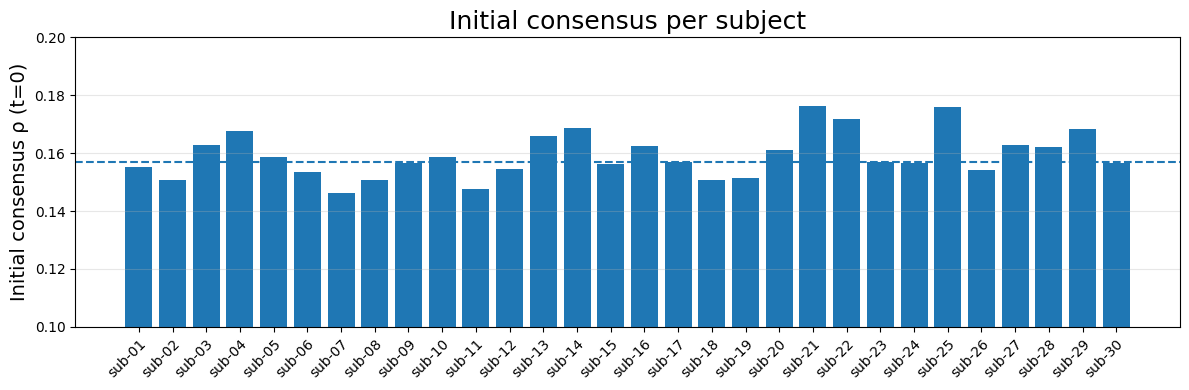

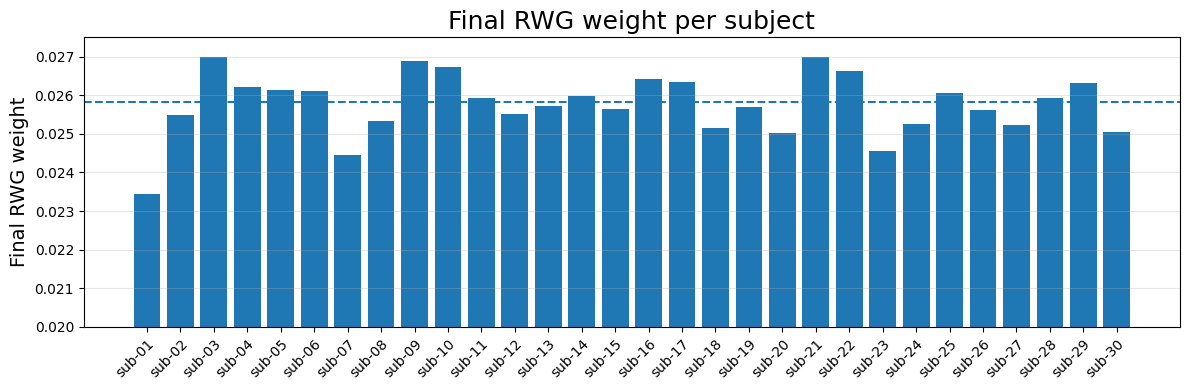

In [ ]:
def rwg_subject_initial_consensus_and_weights(
    fmri_rdm_dir: str | Path,
    norm: str = "zscore",
    corr_mode: str = "pearson",
    weight_mode: str = "tukey",
    tau: float = 0.05,
) -> Dict[str, Any]:
    """
    Returns the per-subject initial consensus (rho wrt the *initial* centroid)
    and the *final* RWG subject weight.

    Output dict:
      {
        "subject_ids": [ ... ],
        "initial_consensus_rho": np.ndarray [S],     # rho at t=0 vs median centroid
        "initial_consensus_dist": np.ndarray [S],    # 1 - rho (optional convenience)
        "final_weights": np.ndarray [S],             # RWG weights after convergence
        "iters": int,                                # iterations until stop
        "vector_dim": int,                           # D
      }
    """
    base = Path(fmri_rdm_dir)
    sub_dirs = sorted(base.glob("sub-*"))
    if not sub_dirs:
        raise FileNotFoundError(f"No subject directories matching 'sub-*' under: {base}")

    subject_ids = [d.name for d in sub_dirs]

    # --- 1) Build a "subject embedding" per subject via ROI-level RWG ---
    subj_embeddings: List[np.ndarray] = []
    for sub in sub_dirs:
        roi_files = sorted(sub.glob("*.npy"))
        if not roi_files:
            raise FileNotFoundError(f"No ROI .npy files under: {sub}")

        roi_vecs = [np.load(f).astype(np.float32).ravel() for f in roi_files]
        first_shape = roi_vecs[0].shape
        if any(v.shape != first_shape for v in roi_vecs):
            raise ValueError(f"ROI vector shapes differ for {sub}")

        E_roi = np.stack(roi_vecs, axis=0).astype(np.float32)  # (R, D)
        # ROI-level RWG to get a subject embedding (same defaults as your pipeline)
        _, subj_mean, _, _ = _iterative_reweight(
            E_roi
        )
        subj_embeddings.append(subj_mean.astype(np.float32))

    # --- 2) Stack subject embeddings and run subject-level RWG ---
    E_subj = np.stack(subj_embeddings, axis=0).astype(np.float32)  # (S, D)
    w_final, _, iters, E_norm = _iterative_reweight(
        E_subj
    )

    # --- 3) Compute initial consensus rho at t=0 ---
    # Uses the same normalized matrix E_norm that _iterative_reweight used internally.
    # Initial centroid is the elementwise median of E_norm (before any updates).
    E_center = E_norm - E_norm.mean(axis=1, keepdims=True)
    row_norms = np.linalg.norm(E_center, axis=1)

    E_mean0 = np.median(E_norm, axis=0)
    mean_center0 = E_mean0 - E_mean0.mean()

    denom = row_norms * (np.linalg.norm(mean_center0) + 1e-9)
    numer = E_center @ mean_center0
    rho0 = numer / np.where(denom == 0, 1e-9, denom)
    rho0 = np.clip(rho0, -0.999999, 0.999999)

    return {
        "subject_ids": subject_ids,
        "initial_consensus_rho": rho0.astype(np.float32),
        "initial_consensus_dist": (1.0 - rho0).astype(np.float32),
        "final_weights": w_final.astype(np.float32),
        "iters": int(iters),
        "vector_dim": int(E_subj.shape[1]),
    }

def _numeric_subject_order(ids: List[str]) -> np.ndarray:
    def _num(s):
        import re
        m = re.search(r'(\d+)', s)
        return int(m.group(1)) if m else 1_000_000
    return np.argsort([_num(x) for x in ids])

def plot_rwg_subject_bars(
    subject_ids: List[str],
    initial_rho: np.ndarray,
    final_weights: np.ndarray,
    sort: str = "id",  # "none" | "id" | "rho" | "weight"
    normalize_weights: bool = False,
    annotate: bool = False,
    save_prefix: str | Path | None = None,
    title_fs: int = 18,
    axis_label_fs: int = 14,
    xtick_fs: int = 10,
    xtick_rotation: int = 45,
):
    subject_ids = list(subject_ids)
    initial_rho = np.asarray(initial_rho, dtype=np.float32).ravel()
    final_weights = np.asarray(final_weights, dtype=np.float32).ravel()

    if normalize_weights:
        sw = final_weights.sum()
        if sw > 0:
            final_weights = final_weights / sw

    if sort == "rho":
        order = np.argsort(-initial_rho)
    elif sort == "weight":
        order = np.argsort(-final_weights)
    elif sort == "id":
        order = _numeric_subject_order(subject_ids)
    else:
        order = np.arange(len(subject_ids))

    subs = [subject_ids[i] for i in order]
    rho  = initial_rho[order]
    w    = final_weights[order]

    # --- Figure 1: initial consensus rho ---
    fig1, ax1 = plt.subplots(figsize=(max(8, 0.4*len(subs)), 4))
    ax1.bar(np.arange(len(subs)), rho)
    ax1.set_xticks(np.arange(len(subs)))
    ax1.set_xticklabels(subs, rotation=xtick_rotation, ha="right", rotation_mode="anchor")
    ax1.tick_params(axis="x", labelsize=xtick_fs)
    ax1.set_ylabel("Initial consensus ρ (t=0)", fontsize=axis_label_fs)
    ax1.set_title("Initial consensus per subject", fontsize=title_fs)
    ax1.axhline(float(np.median(rho)), linestyle="--")
    ax1.grid(True, axis="y", alpha=0.3)
    ax1.set_ylim(0.1, 0.2)
    fig1.subplots_adjust(bottom=0.28)  # give rotated ticks room
    plt.tight_layout()
    fig1.show()

    # --- Figure 2: final weights ---
    fig2, ax2 = plt.subplots(figsize=(max(8, 0.4*len(subs)), 4))
    ax2.bar(np.arange(len(subs)), w)
    ax2.set_xticks(np.arange(len(subs)))
    ax2.set_xticklabels(subs, rotation=xtick_rotation, ha="right", rotation_mode="anchor")
    ax2.tick_params(axis="x", labelsize=xtick_fs)
    ax2.set_ylabel("Final RWG weight" + (" (normalized)" if normalize_weights else ""), fontsize=axis_label_fs)
    ax2.set_title("Final RWG weight per subject", fontsize=title_fs)
    ax2.axhline(float(np.median(w)), linestyle="--")
    ax2.grid(True, axis="y", alpha=0.3)
    ax2.set_ylim(0.02, 0.0275)
    fig2.subplots_adjust(bottom=0.28)
    plt.tight_layout()
    fig2.show()

res = rwg_subject_initial_consensus_and_weights(
    fmri_rdm_dir=FMRI_PATH, 
    norm="zscore",
    corr_mode="pearson",
    weight_mode="huber",
    tau=0.05,
)

plot_rwg_subject_bars(
    subject_ids=res["subject_ids"],
    initial_rho=res["initial_consensus_rho"],
    final_weights=res["final_weights"],
    sort="id",
    normalize_weights=False,
    annotate=False,
    save_prefix="rwg_subject_hist.png"
)




## Subject Distribution Figure
: mean of Spearman score to other subjects

In [ ]:
def plot_roi_topbottom_bars(scores_raw: np.ndarray,
                            region_names: list[str],
                            subjects: list[int],
                            out_dir: Path | None = None,
                            k: int = 5,
                            fixed_ylim: tuple[float, float] | None = None,
                            share_y: bool = True,
                            ncols: int = 5,
                            dpi: int = 600,
                            suptitle_fs: int = 22,
                            subplot_title_fs: int = 22,
                            axis_label_fs: int = 22,
                            xtick_fs: int = 15,
                            ytick_fs: int = 12,
                            xtick_rotation: int = 45,
                            row_hspace: float = 0.65,
                            col_wspace: float = 0.35):
    
    # out_dir is optional now; in a notebook can pass None
    if out_dir is not None:
        ensure_dir(out_dir)

    R, S = scores_raw.shape
    nrows = int(np.ceil(R / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(ncols * 4.6, nrows * 4.2),
                             dpi=dpi)
    axes = np.array(axes).reshape(-1)

    bottom_means = np.zeros(R, dtype=np.float32)
    top_means    = np.zeros(R, dtype=np.float32)

    for ri in range(R):
        ax = axes[ri]
        vals = scores_raw[ri, :]

        order   = np.argsort(vals)
        bot_idx = order[:k]
        top_idx = order[-k:][::-1]
        sel_idx = np.concatenate([bot_idx, top_idx])

        sel_vals   = vals[sel_idx]
        sel_labels = [str(subjects[i] + 1) for i in sel_idx]
        sel_colors = (["#D62728"] * k) + (["#4C78A8"] * k)

        # store per-ROI means
        bottom_means[ri] = float(np.nanmean(vals[bot_idx]))
        top_means[ri]    = float(np.nanmean(vals[top_idx]))

        # y-limits
        if share_y and fixed_ylim is not None:
            ax.set_ylim(*fixed_ylim)
        else:
            vmin, vmax = float(np.nanmin(sel_vals)), float(np.nanmax(sel_vals))
            margin = 0.05 * (vmax - vmin + 1e-12)
            ax.set_ylim(vmin - margin, vmax + margin)

        # bars
        ax.axhline(0.0, lw=0.7, alpha=0.7)
        xs = np.arange(2 * k)
        ax.bar(xs, sel_vals, color=sel_colors,
               edgecolor="black", linewidth=0.4)
        ax.axvline(k - 0.5, color="black", lw=0.8, alpha=0.35)

        # titles / labels
        ax.set_title(region_names[ri].upper(), fontsize=subplot_title_fs, pad=6)

        ax.set_xticks(xs)
        ax.set_xticklabels(sel_labels,
                           fontsize=xtick_fs,
                           rotation=xtick_rotation,
                           ha="right",
                           rotation_mode="anchor")
        ax.set_xlabel("Subject", fontsize=axis_label_fs, labelpad=3)
        ax.tick_params(axis='y', labelsize=ytick_fs)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.5)

    for j in range(R, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Top-{k} and Bottom-{k} subjects per ROI",
                 fontsize=suptitle_fs, y=0.97)

    fig.subplots_adjust(left=0.07, right=0.98,
                        bottom=0.08, top=0.80,
                        wspace=col_wspace, hspace=row_hspace)
    
    fig.text(
        0.015, 0.5,
        "Mean Spearman correlation",
        fontsize=axis_label_fs,
        rotation="vertical",
        va="center",
        ha="center"
    )

    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#D62728", edgecolor="black",
              label=f"Bottom-{k}"),
        Patch(facecolor="#4C78A8", edgecolor="black",
              label=f"Top-{k}")
    ]
    fig.legend(handles=handles,
               loc="upper center",
               bbox_to_anchor=(0.5, 0.89),
               frameon=False,
               fontsize=axis_label_fs,
               ncol=2)

    plt.show()
    return bottom_means, top_means



N_COLS      = 5 
K           = 5
SHARE_Y     = True
FIXED_YLIM  = (-0.002, 0.02)
DPI         = 600

# 1) Load E[S, R, D]
E = scan_rdms(FMRI_PATH, REGION_NAMES)
S, R, D = E.shape

# 2) Select subjects
S_sel = min(N_SUBJECTS_DEFAULT, S)
subjects = list(range(S_sel))
if S < N_SUBJECTS_DEFAULT:
    print(f"[INFO] Only {S} subjects available; using 0..{S-1}.")
else:
    print(f"[INFO] Using subjects 0..{S_sel-1} (total {S_sel}).")

# 3) Compute mean Spearman-to-others per ROI
scores_raw = compute_subject_correlation_scores(
    E, REGION_NAMES, subjects, corr_kind=CORR_KIND, agg=AGG_KIND
)

# 4) Plot and get per-ROI bottom/top means
bottom_means, top_means = plot_roi_topbottom_bars(
    scores_raw, REGION_NAMES, subjects,
    out_dir=None,
    k=K,
    share_y=SHARE_Y,
    fixed_ylim=FIXED_YLIM,
    ncols=N_COLS,
    dpi=DPI,
)

# 5) Print the averages for each ROI
print("\nPer-ROI mean correlations (bottom-5 vs top-5):")
for roi, b, t in zip(REGION_NAMES, bottom_means, top_means):
    print(f"{roi:>4}: bottom-5 mean = {b: .6f},   top-5 mean = {t: .6f}")


[INFO] Using subjects 0..29 (total 30).



Per-ROI mean correlations (bottom-5 vs top-5):
  v1: bottom-5 mean =  0.000374,   top-5 mean =  0.005105
  v2: bottom-5 mean = -0.000411,   top-5 mean =  0.004658
  v3: bottom-5 mean = -0.001237,   top-5 mean =  0.003412
  v4: bottom-5 mean = -0.000855,   top-5 mean =  0.003578
  v8: bottom-5 mean = -0.001609,   top-5 mean =  0.003891
 lo1: bottom-5 mean =  0.000156,   top-5 mean =  0.005170
 lo2: bottom-5 mean =  0.004205,   top-5 mean =  0.015219
 lo3: bottom-5 mean =  0.001383,   top-5 mean =  0.007219
 pit: bottom-5 mean =  0.002080,   top-5 mean =  0.007840
 vvc: bottom-5 mean =  0.001366,   top-5 mean =  0.009576
 ffc: bottom-5 mean =  0.003201,   top-5 mean =  0.013865
vmv1: bottom-5 mean = -0.000417,   top-5 mean =  0.001779
vmv2: bottom-5 mean =  0.001304,   top-5 mean =  0.006646
vmv3: bottom-5 mean =  0.000163,   top-5 mean =  0.006098


## RWG vs SM figure
: Averaged spearman score for each ROI across all 89 architectures. <br>
    Computed the spearman score both simple mean and RWG, and displayed the percent increase.

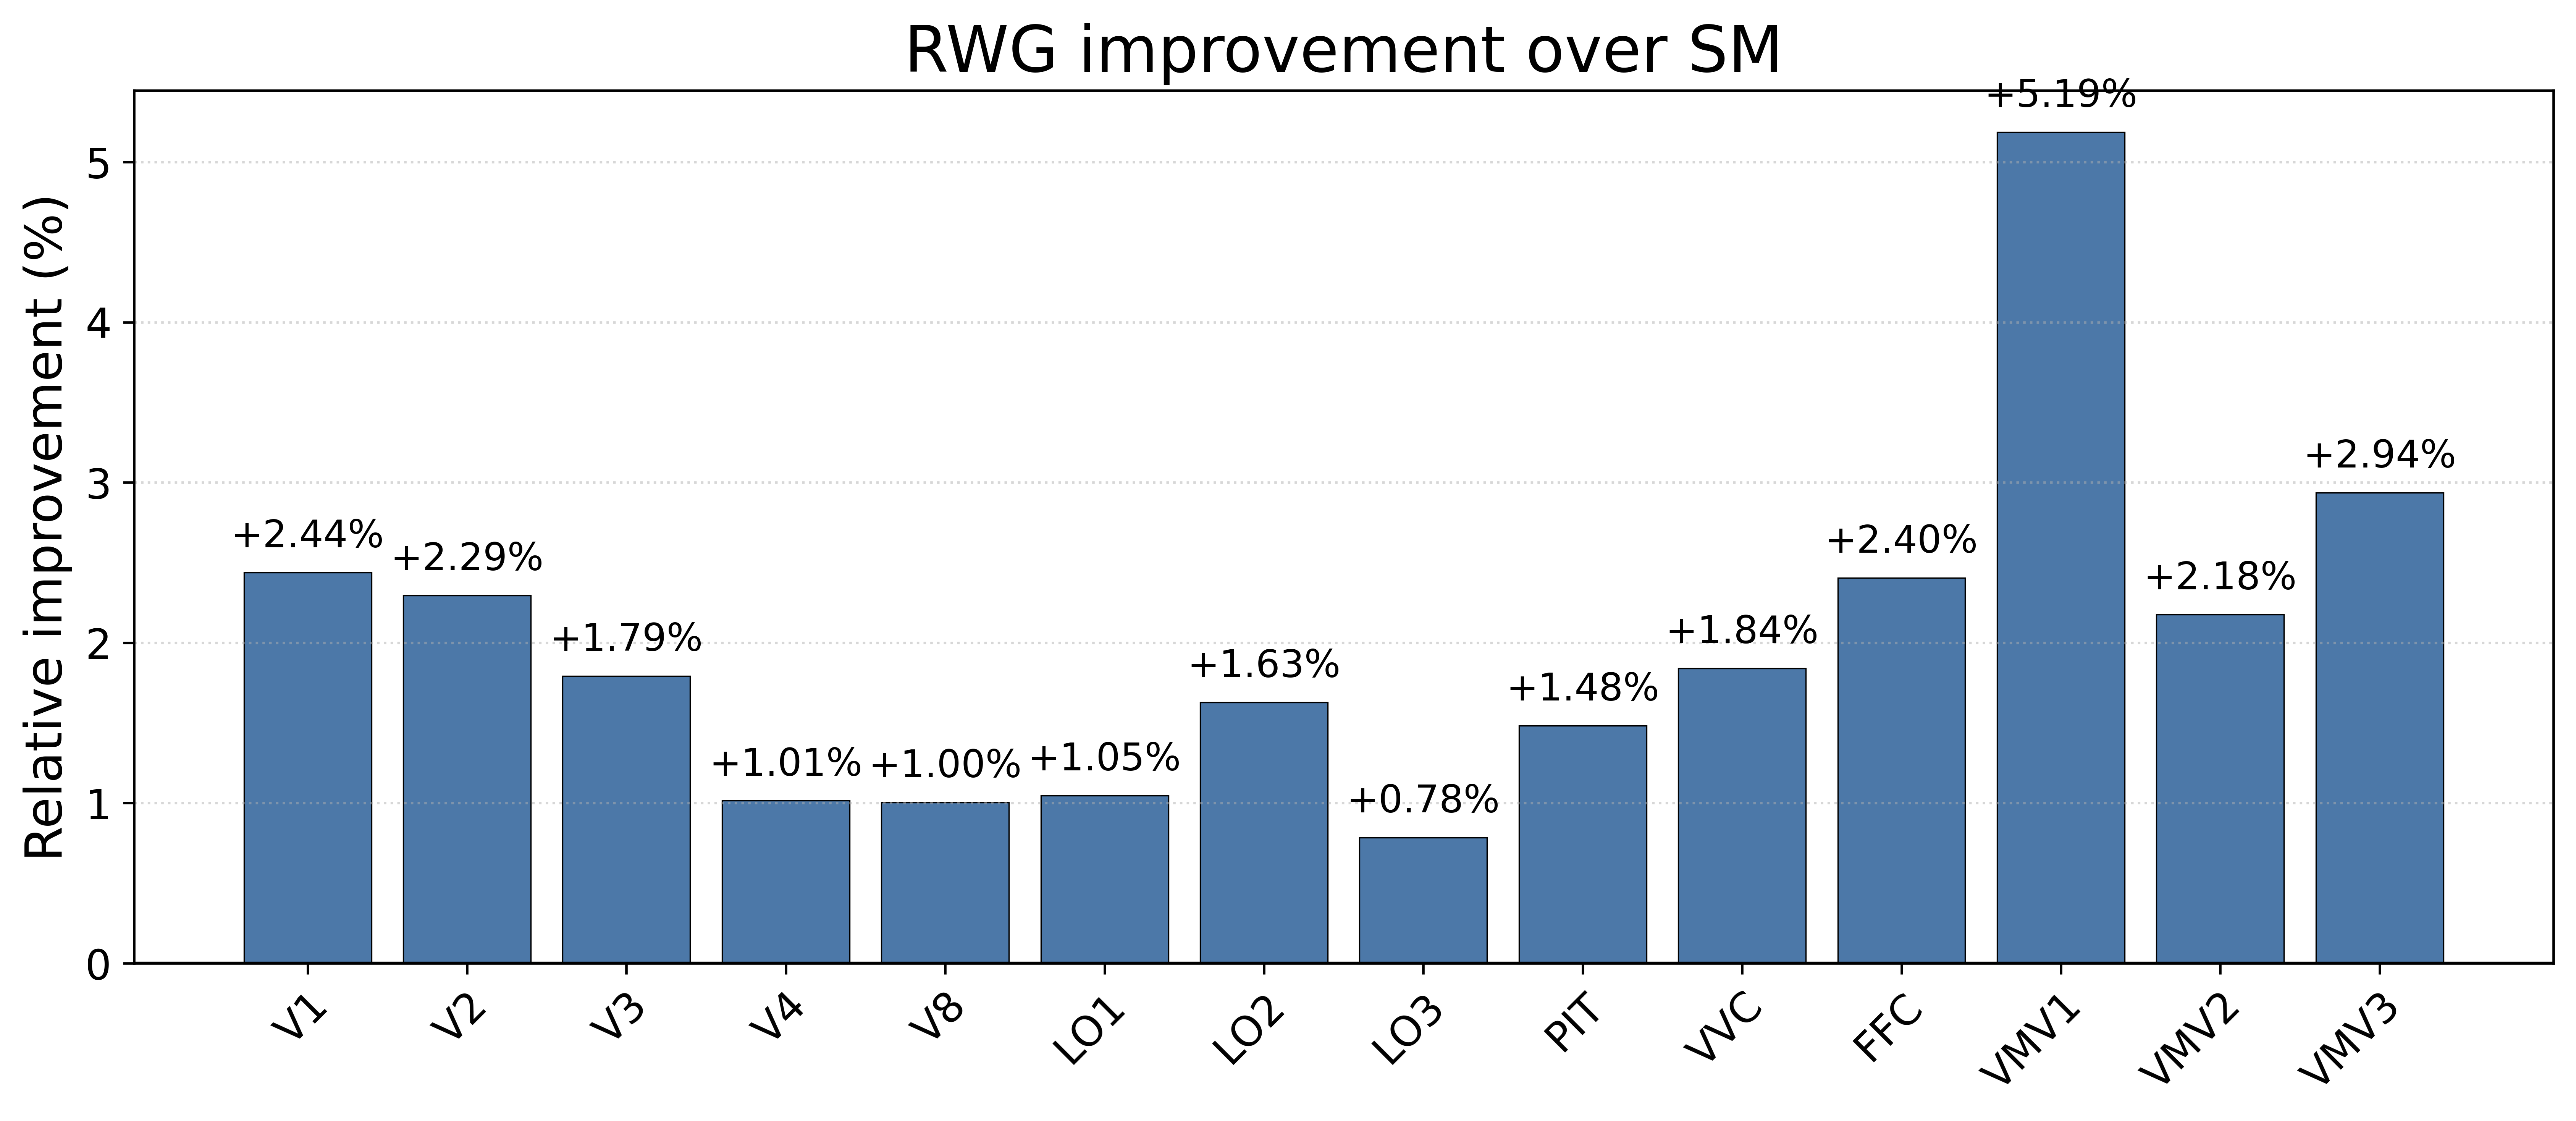

In [ ]:
EXCEL    = Path("result.xlsx")
SHEET    = 0
OUT_PNG  = Path("/RWG_SM/roi_avg_spearman_bars.png")
OUT_CSV  = Path("/RWG_SM/roi_avg_spearman_averages.csv")
ROI_ORDER = [
    "V1","V2","V3","V4","V8",
    "LO1","LO2","LO3","PIT","VVC","FFC",
    "VMV1","VMV2","VMV3",
]

def _find_col(candidates, cols):
    lc_cols = {c.lower(): c for c in cols}
    for cand in candidates:
        cand_l = cand.lower()
        if cand_l in lc_cols:
            return lc_cols[cand_l]
        for k_l, orig in lc_cols.items():
            if cand_l in k_l:
                return orig
    raise KeyError(f"None of {candidates} found in columns {list(cols)}")

def _clean_roi_series(s: pd.Series) -> pd.Series:
    """Turn names like 'FFC_roi_rdm_vector' into 'FFC'."""
    def _one(name: str) -> str:
        n = str(name)
        n = re.split(r'[\\/|]', n)[-1].strip()
        n = re.sub(r'^(roi[_\-\s:]+)', '', n, flags=re.IGNORECASE)
        n = re.sub(r'(?i)(_roi)?_rdm_vectors?$', '', n)
        n = re.sub(r'(?i)_roi_rdm_vector$', '', n)
        n = re.sub(r'(?i)_rdm_vector$', '', n)
        n = re.sub(r'(?i)_vector$', '', n)
        n = re.sub(r'(?i)_roi$', '', n)
        return n.strip(" _-")
    return s.astype(str).apply(_one)

def load_and_aggregate(
    excel_path: Path,
    sheet: str | int = 0,
    arch_candidates = ("arch",),
    roi_candidates  = ("roi",),
    simple_candidates = ("d_vs_roi_simple", "simple", "spearman_simple"),
    rwg_candidates    = ("d_vs_roi_reweighted", "rwg", "reweighted", "spearman_rwg", "spearman_reweighted"),
):
    """Read Excel, clean ROI labels, and average scores across architectures per ROI."""
    df = pd.read_excel(excel_path, sheet_name=sheet)

    arch_col   = _find_col(arch_candidates, df.columns)
    roi_col    = _find_col(roi_candidates, df.columns)
    simple_col = _find_col(simple_candidates, df.columns)
    rwg_col    = _find_col(rwg_candidates, df.columns)

    df = df[[arch_col, roi_col, simple_col, rwg_col]].copy()
    df[simple_col] = pd.to_numeric(df[simple_col], errors="coerce")
    df[rwg_col]    = pd.to_numeric(df[rwg_col], errors="coerce")
    df = df.dropna(subset=[roi_col, simple_col, rwg_col])

    # Clean ROI text (e.g., "FFC_roi_rdm_vector" -> "FFC")
    df["ROI"] = _clean_roi_series(df[roi_col])

    # Average across architectures grouped by cleaned ROI
    g = df.groupby("ROI", observed=True).agg(
        Simple=(simple_col, "mean"),
        RWG=(rwg_col, "mean"),
        n_rows=(simple_col, "size"),
    ).reset_index()

    # Percent change column for CSV convenience
    eps = 1e-12
    g["DeltaPct_RWG_vs_Simple"] = (g["RWG"] - g["Simple"]) / np.maximum(np.abs(g["Simple"]), eps) * 100.0

    return g, "ROI"

def reorder_by_roi_list(g: pd.DataFrame, roi_col: str, desired_order: list[str]) -> pd.DataFrame:
    """
    Reorder/filter the grouped dataframe to match a desired ROI order (case-insensitive).
    X-axis labels appear exactly as provided in desired_order.
    """
    gg = g.copy()
    gg["_key"] = gg[roi_col].astype(str).str.lower()
    row_map = {k: row for k, row in gg.set_index("_key").iterrows()}

    rows = []
    labels = []
    for label in desired_order:
        k = label.lower()
        if k in row_map:
            rows.append(row_map[k])
            labels.append(label)

    if not rows:
        return pd.DataFrame(columns=["ROI_label","Simple","RWG","n_rows","DeltaPct_RWG_vs_Simple"])

    out = pd.DataFrame(rows).reset_index(drop=True)
    out["ROI_label"] = labels
    return out[["ROI_label","Simple","RWG","n_rows","DeltaPct_RWG_vs_Simple"]]

def plot_grouped_bars_with_pct(
    g: pd.DataFrame,
    out_png: Path | None,
    title: str | None = "Per-ROI average Spearman score",
    dpi: int = 600,
    title_fs: int = 20,
    y_label_fs: int = 16,
    tick_fs: int = 13,
    legend_fs: int = 13,
    ann_fs: int = 12,
    xtick_rotation: int = 45,
    bar_width: float = 0.42,
    headroom: float = 0.14,
):
    rois   = g["ROI_label"].astype(str).tolist()
    simple = g["Simple"].to_numpy(dtype=float)
    rwg    = g["RWG"].to_numpy(dtype=float)

    N = len(rois)
    x = np.arange(N, dtype=float)
    width = bar_width

    fig_w = max(12.0, 0.75 * N)
    fig_h = 6.2
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    ax.bar(x - width/2, simple, width, label="SM")
    ax.bar(x + width/2, rwg,    width, label="RWG")

    ax.set_xticks(x)
    ax.set_xticklabels(rois, rotation=xtick_rotation, ha="right", rotation_mode="anchor", fontsize=tick_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)

    ax.set_ylabel("Average Spearman score (across architectures)", fontsize=y_label_fs)
    if title:
        ax.set_title(title, fontsize=title_fs)
    ax.legend(fontsize=legend_fs)
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.5)

    eps = 1e-12
    pct_change = (rwg - simple) / np.maximum(np.abs(simple), eps) * 100.0
    y_max = np.maximum(simple, rwg)

    y_all   = np.r_[simple, rwg]
    data_lo = float(np.nanmin(y_all)) if y_all.size else 0.0
    data_hi = float(np.nanmax(y_all)) if y_all.size else 1.0
    rng     = max(data_hi - data_lo, 1e-9)
    offset  = 0.02 * rng

    ax.set_ylim(data_lo, data_hi + rng * headroom)

    for i, pct in enumerate(pct_change):
        ax.text(
            x[i],
            y_max[i] + offset,
            f"{pct:+.2f}%",
            ha="center",
            va="bottom",
            fontsize=ann_fs,
            clip_on=False,
        )

    ax.margins(x=0.02)
    fig.subplots_adjust(bottom=0.22, left=0.09, right=0.98, top=0.90)
    plt.show()

    if out_png is not None:
        fig.savefig(out_png, bbox_inches="tight")
        plt.close(fig)
        
def _delta_metric(simple, rwg, mode="percent_change"):
    """percent_change: ((rwg - simple)/simple)*100; symmetric: 200*(rwg-simple)/(rwg+simple)"""
    eps = 1e-12
    simple = np.asarray(simple, float); rwg = np.asarray(rwg, float)
    if mode == "percent_change":
        return (rwg - simple) / np.maximum(np.abs(simple), eps) * 100.0, "Relative improvement (%)"
    elif mode == "symmetric":
        return 200.0 * (rwg - simple) / np.maximum(np.abs(rwg) + np.abs(simple), eps), "Symmetric percent difference (%)"
    else:
        raise ValueError("mode must be 'percent_change' or 'symmetric'")

def plot_roi_delta_bars(
    g: pd.DataFrame,
    title: str = "RWG improvement over SM",
    mode: str = "percent_change", # or "symmetric"
    dpi: int = 600,
    title_fs: int = 20, axis_fs: int = 16, tick_fs: int = 13,
    xtick_rotation: int = 45,
    annotate: bool = True, ann_fs: int = 12,
):
    rois   = g["ROI_label"].astype(str).to_numpy()
    simple = g["Simple"].to_numpy(float)
    rwg    = g["RWG"].to_numpy(float)

    delta, ylab = _delta_metric(simple, rwg, mode=mode)

    x = np.arange(len(rois))
    fig_w = max(12.0, 0.75 * len(rois))
    fig, ax = plt.subplots(figsize=(fig_w, 5.6), dpi=dpi)

    colors = ["#4C78A8" if d >= 0 else "#D62728" for d in delta]
    ax.bar(x, delta, color=colors, edgecolor="black", linewidth=0.4)
    ax.axhline(0, linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(rois, rotation=xtick_rotation, ha="right", rotation_mode="anchor", fontsize=tick_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)
    ax.set_ylabel(ylab, fontsize=axis_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.5)

    if annotate:
        ylim = ax.get_ylim()
        rng  = max(ylim[1] - ylim[0], 1e-9)
        for i, d in enumerate(delta):
            ax.text(x[i], d + (0.02*rng if d >= 0 else -0.02*rng),
                    f"{d:+.2f}%", ha="center", va="bottom" if d >= 0 else "top",
                    fontsize=ann_fs)

    fig.subplots_adjust(bottom=0.22, left=0.10, right=0.98, top=0.90)
    plt.show()




g, roi_col = load_and_aggregate(EXCEL, SHEET)
g_ord = reorder_by_roi_list(g, roi_col, ROI_ORDER)

g_plot = g_ord.rename(columns={"ROI": "ROI_label"})
plot_roi_delta_bars(g_plot)

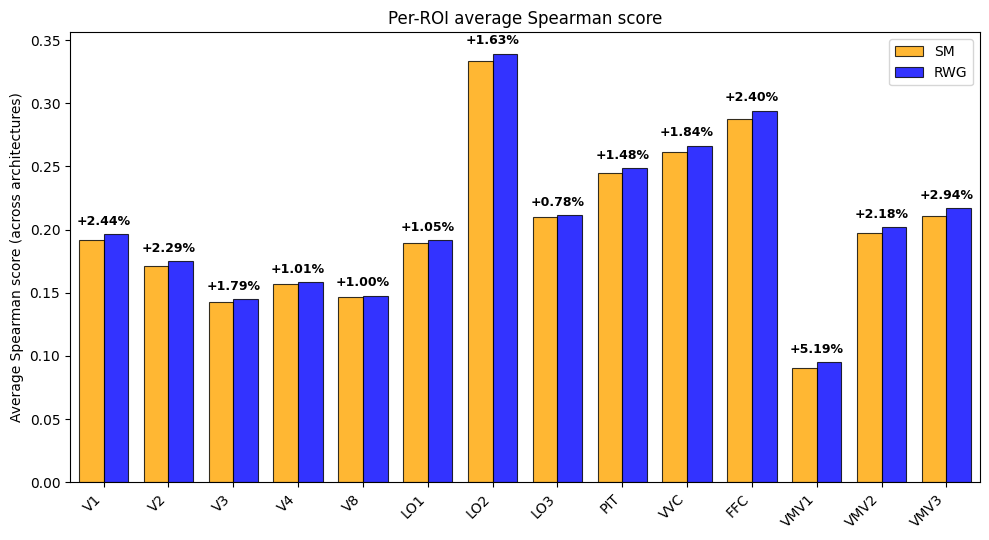

In [ ]:
#!/usr/bin/env python3
"""
Plot per-ROI averaged Spearman score (across architectures) for Simple vs RWG,
enforcing a specific x-axis order and annotating % change above each ROI's bars.

Usage:
  - Edit the EXCEL/SHEET/OUT_PNG/OUT_CSV/ROI_ORDER variables below, or
  - Call run(excel=..., sheet=..., out_png=..., out_csv=..., roi_order=[...])
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

EXCEL    = Path("result.xlsx")
SHEET    = 0
OUT_PNG  = Path("roi_avg_spearman_bars_colored.png")
OUT_CSV  = Path("roi_avg_spearman_averages.csv")
ROI_ORDER = [
    "V1","V2","V3","V4","V8",
    "LO1","LO2","LO3","PIT","VVC","FFC",
    "VMV1","VMV2","VMV3",
]

def _find_col(candidates, cols):
    lc_cols = {c.lower(): c for c in cols}
    for cand in candidates:
        cand_l = cand.lower()
        if cand_l in lc_cols:
            return lc_cols[cand_l]
        for k_l, orig in lc_cols.items():
            if cand_l in k_l:
                return orig
    raise KeyError(f"None of {candidates} found in columns {list(cols)}")

def _clean_roi_series(s: pd.Series) -> pd.Series:
    """Turn names like 'FFC_roi_rdm_vector' into 'FFC'."""
    def _one(name: str) -> str:
        n = str(name)
        n = re.split(r'[\\/|]', n)[-1].strip()
        n = re.sub(r'^(roi[_\-\s:]+)', '', n, flags=re.IGNORECASE)
        n = re.sub(r'(?i)(_roi)?_rdm_vectors?$', '', n)
        n = re.sub(r'(?i)_roi_rdm_vector$', '', n)
        n = re.sub(r'(?i)_rdm_vector$', '', n)
        n = re.sub(r'(?i)_vector$', '', n)
        n = re.sub(r'(?i)_roi$', '', n)
        return n.strip(" _-")
    return s.astype(str).apply(_one)

def load_and_aggregate(
    excel_path: Path,
    sheet: str | int = 0,
    arch_candidates = ("arch",),
    roi_candidates  = ("roi",),
    simple_candidates = ("d_vs_roi_simple", "simple", "spearman_simple"),
    rwg_candidates    = ("d_vs_roi_reweighted", "rwg", "reweighted", "spearman_rwg", "spearman_reweighted"),
):
    df = pd.read_excel(excel_path, sheet_name=sheet)

    arch_col   = _find_col(arch_candidates, df.columns)
    roi_col    = _find_col(roi_candidates, df.columns)
    simple_col = _find_col(simple_candidates, df.columns)
    rwg_col    = _find_col(rwg_candidates, df.columns)

    df = df[[arch_col, roi_col, simple_col, rwg_col]].copy()
    df[simple_col] = pd.to_numeric(df[simple_col], errors="coerce")
    df[rwg_col]    = pd.to_numeric(df[rwg_col], errors="coerce")
    df = df.dropna(subset=[roi_col, simple_col, rwg_col])

    # Clean ROI text (e.g., "FFC_roi_rdm_vector" -> "FFC")
    df["ROI"] = _clean_roi_series(df[roi_col])

    # Average across architectures grouped by cleaned ROI
    g = df.groupby("ROI", observed=True).agg(
        Simple=(simple_col, "mean"),
        RWG=(rwg_col, "mean"),
        n_rows=(simple_col, "size"),
    ).reset_index()

    # Percent change column for CSV convenience
    eps = 1e-12
    g["DeltaPct_RWG_vs_Simple"] = (g["RWG"] - g["Simple"]) / np.maximum(np.abs(g["Simple"]), eps) * 100.0

    return g, "ROI"

def reorder_by_roi_list(g: pd.DataFrame, roi_col: str, desired_order: list[str]) -> pd.DataFrame:
    """
    Reorder/filter the grouped dataframe to match a desired ROI order (case-insensitive).
    X-axis labels appear exactly as provided in desired_order.
    """
    gg = g.copy()
    gg["_key"] = gg[roi_col].astype(str).str.lower()
    row_map = {k: row for k, row in gg.set_index("_key").iterrows()}

    rows = []
    labels = []
    for label in desired_order:
        k = label.lower()
        if k in row_map:
            rows.append(row_map[k])
            labels.append(label)

    if not rows:
        return pd.DataFrame(columns=["ROI_label","Simple","RWG","n_rows","DeltaPct_RWG_vs_Simple"])

    out = pd.DataFrame(rows).reset_index(drop=True)
    out["ROI_label"] = labels
    return out[["ROI_label","Simple","RWG","n_rows","DeltaPct_RWG_vs_Simple"]]

def plot_grouped_bars_with_pct(
    g: pd.DataFrame,
    title: str | None = "Per-ROI average Spearman score",
    dpi: int = 300,
):
    rois = g["ROI_label"].astype(str).tolist()
    simple = g["Simple"].to_numpy(dtype=float)
    rwg    = g["RWG"].to_numpy(dtype=float)

    N = len(rois)
    x = np.arange(N, dtype=float)
    width = 0.38

    fig_w = max(10.0, 0.6 * N)
    fig_h = 5.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.bar(x - width/2, simple, width, label="SM", color='orange', alpha=0.8, edgecolor='black', linewidth=0.8)
    ax.bar(x + width/2, rwg,    width, label="RWG", color='blue', alpha=0.8, edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(rois, rotation=45, ha="right")
    ax.set_ylabel("Average Spearman score (across architectures)")
    if title:
        ax.set_title(title)
    ax.legend()

    eps = 1e-12
    pct_change = (rwg - simple) / np.maximum(np.abs(simple), eps) * 100.0
    y_max = np.maximum(simple, rwg)

    y_all = np.r_[simple, rwg]
    y_range = (np.nanmax(y_all) - np.nanmin(y_all)) if y_all.size else 1.0
    offset = 0.02 * (y_range if y_range > 0 else 1.0)

    for i, pct in enumerate(pct_change):
        ax.text(
            x[i],
            y_max[i] + offset,
            f"{pct:+.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight='bold',
        )

    ax.margins(x=0.01)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

g, roi_col = load_and_aggregate(EXCEL, SHEET)
g_ord = reorder_by_roi_list(g, roi_col, ROI_ORDER)

# Plot
g_plot = g_ord.rename(columns={"ROI": "ROI_label"})
plot_grouped_bars_with_pct(g_plot)

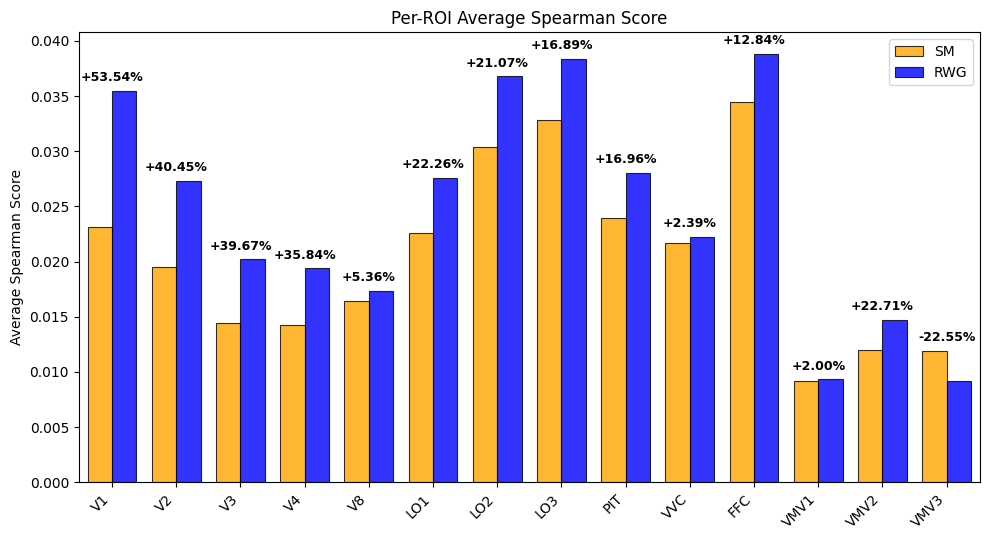

In [ ]:
robust = {"FFC": 0.038829834334740645,
      "LO1": 0.027580470301491633,
      "LO2": 0.036781331189734166,
      "LO3": 0.038366965051548,
      "PIT": 0.028045895595256266,
      "V1": 0.0354590052252066,
      "V2": 0.027332981310854997,
      "V3": 0.020213976134230847,
      "V4": 0.019371037348391296,
      "V8": 0.017337532184014223,
      "VMV1": 0.009309975381627042,
      "VMV2": 0.01471135454860026,
      "VMV3": 0.009213187727922479,
      "VVC": 0.022234073659168026
}


simple = {
      "FFC": 0.034412526252943214,
      "LO1": 0.022558903539821477,
      "LO2": 0.030380638797352023,
      "LO3": 0.032824361196394425,
      "PIT": 0.02397933084492666,
      "V1": 0.023094202586697858,
      "V2": 0.019461288396762387,
      "V3": 0.014472494584531733,
      "V4": 0.014260110010510122,
      "V8": 0.016455993847919376,
      "VMV1": 0.009127794450759282,
      "VMV2": 0.011989170521328087,
      "VMV3": 0.011895128960063044,
      "VVC": 0.02171441938283821
    }

ROI_ORDER = [
    "V1","V2","V3","V4","V8",
    "LO1","LO2","LO3","PIT","VVC","FFC",
    "VMV1","VMV2","VMV3",
]


def plot_difference_simple_vs_robust(
    simple_dict: dict,
    robust_dict: dict,
    title: str | None = "Per-ROI Average Spearman Score",
    roi_order: list[str] = ROI_ORDER,
    dpi: int = 600,
):
    """
    Plot side-by-side comparison of simple and robust (RWG) scores.
    
    Args:
        simple_dict: Dictionary with ROI labels as keys and simple scores as values
        robust_dict: Dictionary with ROI labels as keys and robust scores as values
        out_png: Path to save the output PNG
        title: Title for the plot
        roi_order: Desired order for x-axis labels
        dpi: DPI for the saved figure
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    lc_simple = {k.lower(): (k, v) for k, v in simple_dict.items()}
    lc_robust = {k.lower(): (k, v) for k, v in robust_dict.items()}
    
    rois = []
    simple_vals = []
    robust_vals = []
    
    for roi_label in roi_order:
        roi_key = roi_label.lower()
        if roi_key in lc_simple and roi_key in lc_robust:
            rois.append(roi_label)
            simple_vals.append(lc_simple[roi_key][1])
            robust_vals.append(lc_robust[roi_key][1])
    
    simple = np.array(simple_vals, dtype=float)
    robust = np.array(robust_vals, dtype=float)
    
    eps = 1e-12
    pct_change = (robust - simple) / np.maximum(np.abs(simple), eps) * 100.0
    
    N = len(rois)
    x = np.arange(N, dtype=float)
    width = 0.38
    
    fig_w = max(10.0, 0.6 * N)
    fig_h = 5.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    
    bars1 = ax.bar(x - width/2, simple, width, label="SM", color='orange', alpha=0.8, edgecolor='black', linewidth=0.8)
    bars2 = ax.bar(x + width/2, robust, width, label="RWG", color='blue', alpha=0.8, edgecolor='black', linewidth=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(rois, rotation=45, ha="right")
    ax.set_ylabel("Average Spearman Score")
    if title:
        ax.set_title(title)
    ax.legend(loc='upper right')
    
    y_max = np.maximum(simple, robust)
    y_all = np.r_[simple, robust]
    y_range = (np.nanmax(y_all) - np.nanmin(y_all)) if y_all.size else 1.0
    offset = 0.02 * (y_range if y_range > 0 else 1.0)
    
    for i, pct in enumerate(pct_change):
        ax.text(
            x[i],
            y_max[i] + offset,
            f"{pct:+.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight='bold',
        )
    
    ax.margins(x=0.01)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    
plot_difference_simple_vs_robust(simple, robust)

In [148]:
from src import imagenet_weighted_embeddings as iwe

fmri_path = Path("/home/wallacelab/teba/multimodal_brain_inspired/NOD/Nick_RDMs/outputs")

roi_results = iwe.run_mri_weighting_by_roi(fmri_path)

/tmp/ipykernel_3379800/2273923415.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


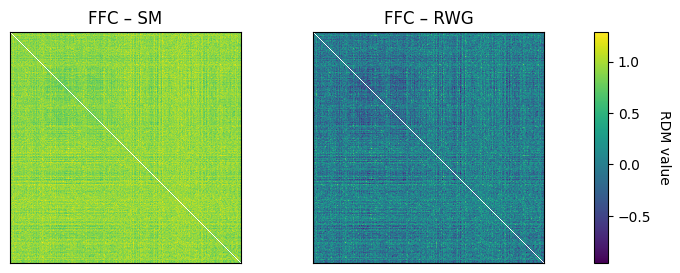

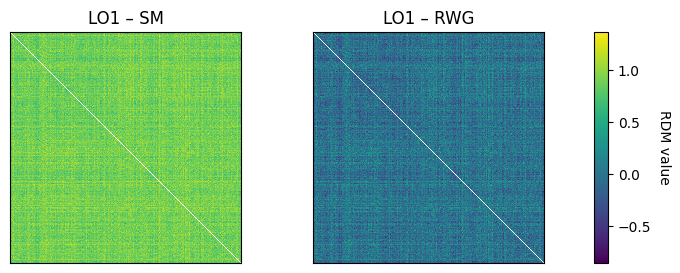

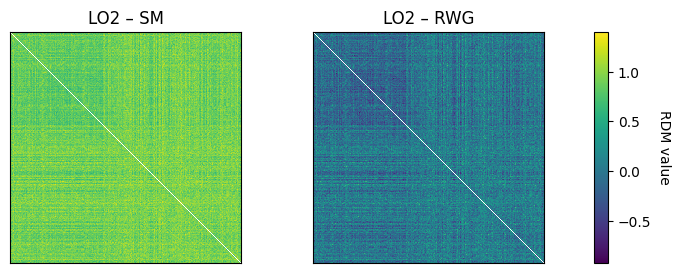

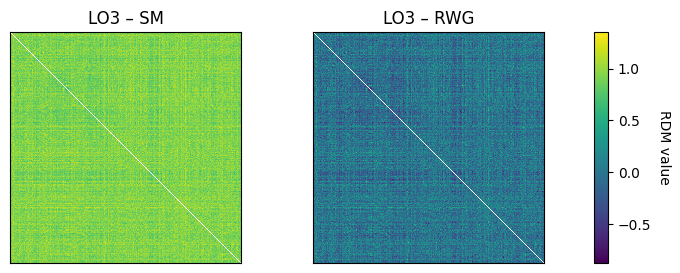

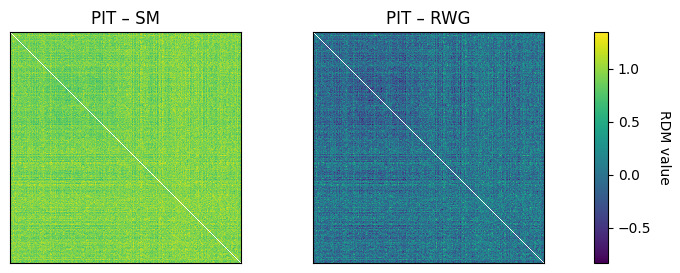

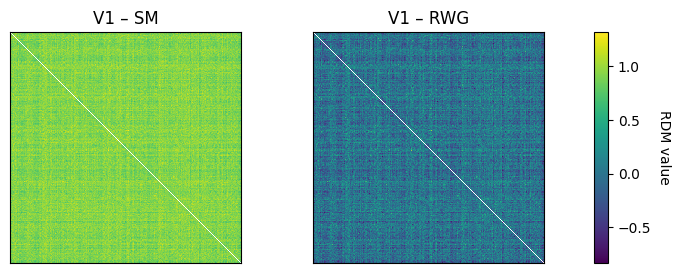

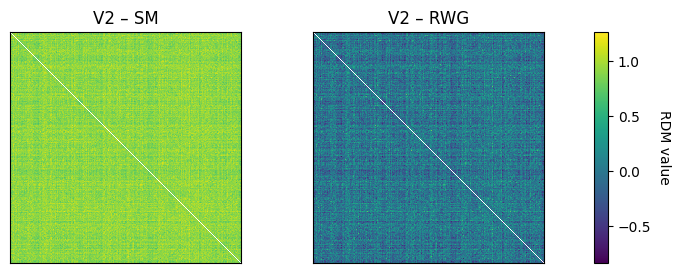

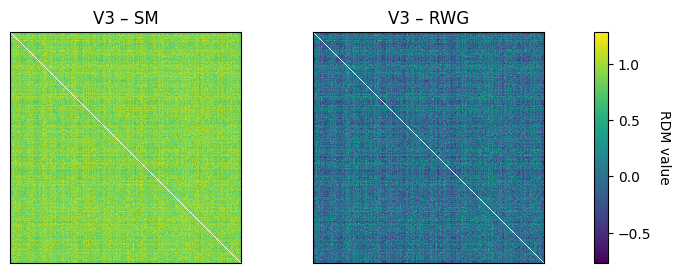

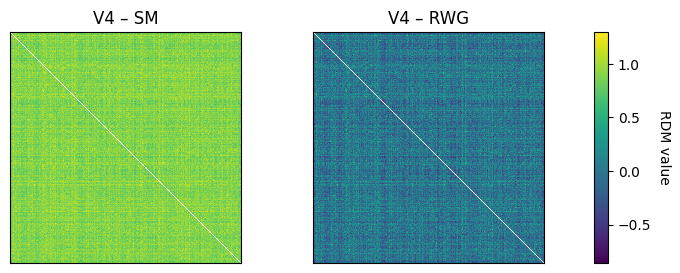

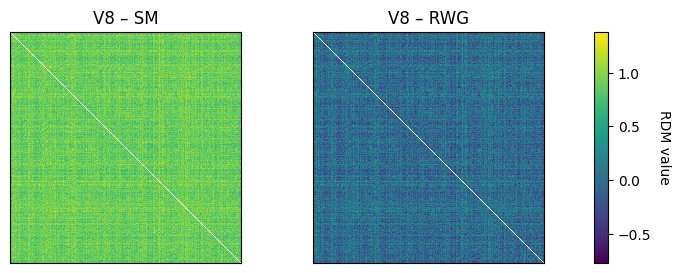

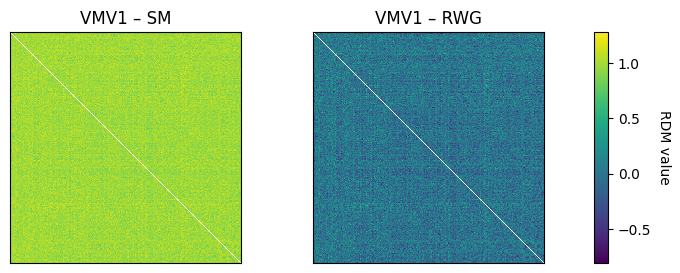

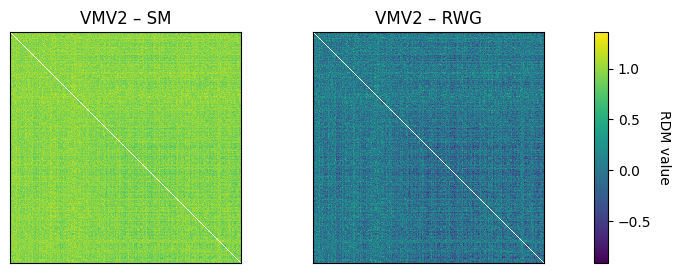

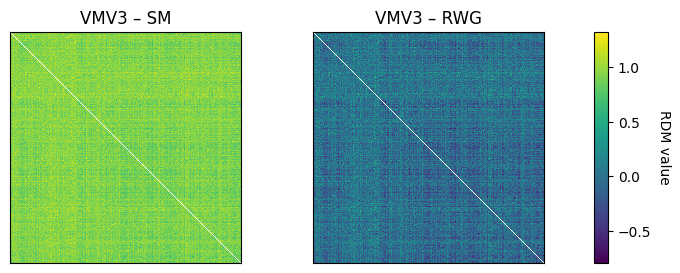

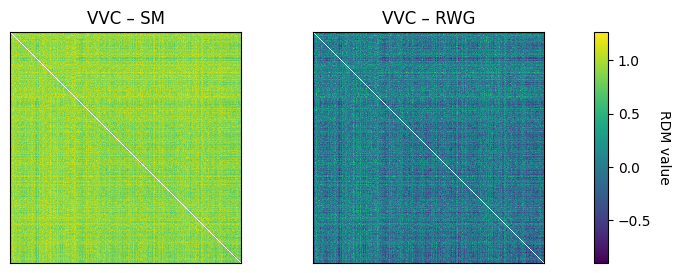

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def vec_to_rdm(vec: np.ndarray) -> np.ndarray:
    """
    Convert a vectorized upper-triangular (k=1) RDM to a full (K, K) matrix.
    vec: shape (D,), D = K*(K-1)/2
    Returns: (K, K) symmetric matrix with NaN on the diagonal.
    """
    vec = np.asarray(vec).ravel()
    D = vec.shape[0]

    K = int(0.5 * (1 + np.sqrt(1 + 8 * D)))
    assert K * (K - 1) // 2 == D, "Vector length is not a valid RDM size."

    rdm = np.zeros((K, K), dtype=vec.dtype)
    iu = np.triu_indices(K, k=1)

    rdm[iu] = vec
    rdm[(iu[1], iu[0])] = vec 

    np.fill_diagonal(rdm, np.nan)

    return rdm

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")

def clean_roi_name(raw_roi: str) -> str:
    suffix = "_roi_rdm_vector"
    if raw_roi.endswith(suffix):
        return raw_roi[:-len(suffix)]
    return raw_roi

for roi, data in roi_results.items():
    roi = clean_roi_name(roi)
    simple_rdm = vec_to_rdm(data["simple_mean"])
    rewt_rdm   = vec_to_rdm(data["reweighted_mean"])

    vmin = np.nanmin([simple_rdm, rewt_rdm])
    vmax = np.nanmax([simple_rdm, rewt_rdm])

    fig = plt.figure(figsize=(8, 3))
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[1, 1, 0.05],
        wspace=0.15,
    )

    ax_simple = fig.add_subplot(gs[0, 0])
    ax_rewt   = fig.add_subplot(gs[0, 1])
    cax       = fig.add_subplot(gs[0, 2])

    axes = [ax_simple, ax_rewt]

    ims = []
    for ax, rdm, title in zip(
        axes,
        [simple_rdm, rewt_rdm],
        ["SM", "RWG"]
    ):
        rdm_masked = np.ma.masked_invalid(rdm)
        im = ax.imshow(
            rdm_masked,
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
        ims.append(im)
        ax.set_title(f"{roi} – {title}")
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(ims[-1], cax=cax)
    cbar.ax.set_ylabel("RDM value")
    cax.yaxis.label.set_rotation(270)
    cax.yaxis.label.set_va("bottom")

    plt.tight_layout()
    plt.show()
    plt.close(fig)